<div align="center">

# Livrable 1 — Classification Automatique d'Images
## Projet DS Leyenda — TouNum

| | |
|:---|:---|
| **Étudiants**  | *BERRETTA BAPTISTE - HIVER ANDREW - KHALED REFKA - GORDIEN ALEXIS* |
| **Promotion**  | *FISA-INFO A5* |
| **École**      | CESI |
| **Date**       | Mai 2026 |
|:---|:---|
</div>

---

### Contexte métier

L'entreprise **TouNum** se spécialise dans la numérisation de documents pour le compte de ses clients.
Dans le cadre de l'automatisation de son pipeline de traitement, il est nécessaire de **trier
automatiquement les images** selon leur nature avant d'appliquer les algorithmes de captioning.

Ce notebook implémente un **réseau de neurones convolutif (CNN)** capable de classifier des images
en **5 catégories** :

| Classe         | Description                             |
|----------------|-----------------------------------------|
| **Painting**   | Peintures et œuvres d'art               |
| **Photo**      | Photographies réelles                   |
| **Schematics** | Schémas, graphes et diagrammes          |
| **Sketch**     | Portraits dessinés en noir et blanc     |
| **Text**       | Documents textuels scannés              |

### Objectif

Entraîner un modèle de **classification automatique** permettant de distinguer les photos des autres
types d'images, avec une attention particulière à la discrimination entre **photos et peintures**
(le cas le plus difficile visuellement).

### Workflow général

```
Données brutes  ──►  Exploration  ──►  Nettoyage  ──►  Prétraitement
                                                              │
           Interface  ◄──  Évaluation  ◄──  Entraînement  ◄───┘
```


---
## Sommaire

| Section | Titre | Description |
|---------|-------|-------------|
| **0** | [Environnement de Travail](#0) | Installation des dépendances, imports, configuration globale |
| **1** | [Exploration du Dataset](#1) | Distribution des classes, exemples visuels, dimensions |
| **1b** | [Nettoyage des Images](#1b) | Détection et correction des fichiers corrompus |
| **2** | [Préparation des Données](#2) | Labels binaires, augmentation, class weights |
| **3** | [Architecture du Réseau](#3) | Conception et justification du CNN à 4 blocs |
| **4** | [Entraînement](#4) | Callbacks, optimisation, suivi de la convergence |
| **5** | [Analyse des Résultats](#5) | Courbes, métriques, matrice de confusion, erreurs |
| **6** | [Biais / Variance](#6) | Diagnostic de l'apprentissage |
| **7** | [Pistes d'Amélioration](#7) | Transfer learning, régularisation avancée |
| **7b** | [Architecture Externe — fakv8](#7b) | fakv8 en mode binaire (un seul modele) |
| **8** | [Transfer Learning — EfficientNetB0](#8tl) | Fine-tuning d'un réseau pré-entraîné sur ImageNet |
| **9** | [Interface Interactive](#9) | Test du modèle en conditions réelles |
| **10** | [Conclusion](#10) | Synthèse des résultats et perspectives |

> **Comment utiliser ce notebook :**
> Exécuter les cellules **dans l'ordre** de haut en bas lors de la première exécution.
> Après un restart du kernel, utiliser la cellule de *Reprise rapide* (Section 5) pour recharger le modèle sauvegardé sans ré-entraîner.


---
## 0. Environnement de Travail <a id="0"></a>

Avant toute chose, on s'assure que l'environnement d'exécution est correctement configuré :

- **Dépendances** : les librairies nécessaires sont installées si absentes
- **Imports** : toutes les bibliothèques Python sont chargées
- **Configuration** : les hyperparamètres et chemins sont définis en un seul endroit

> Centraliser la configuration dans une seule cellule (`cell-config`) permet de modifier
> les paramètres (taille d'image, batch size, learning rate) sans toucher au code métier.


In [2]:
# ============================================================
# INSTALLATION DES DÉPENDANCES
# Utilise l'API interne de pip (pas de subprocess) pour installer
# les packages manquants directement dans l'environnement du kernel.
# ============================================================

from pip._internal.cli.main import main as _pip_install

for _pkg in ['seaborn', 'ipywidgets', 'pandas', 'tqdm']:
    try:
        __import__(_pkg)
        print(f"{_pkg} : déjà installé")
    except ImportError:
        print(f"{_pkg} : installation en cours...")
        _pip_install(['install', '--quiet', _pkg])
        print(f"{_pkg} : installé ✓")

print("\nDépendances OK.")

seaborn : déjà installé
ipywidgets : déjà installé
pandas : déjà installé
tqdm : déjà installé

Dépendances OK.


In [3]:
# ============================================================
# IMPORTS
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Reproductibilité : fixer les seeds pour des résultats cohérents entre exécutions
tf.random.set_seed(42)
np.random.seed(42)

# Style des graphiques
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

# Détection et configuration du GPU
print(f"TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        # memory_growth évite que TF alloue toute la VRAM d'un coup
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU disponible : {gpus[0].name}")
else:
    print("GPU non détecté — entraînement sur CPU (sera plus lent)")

2026-05-28 06:50:01.875596: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 06:50:01.956859: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-28 06:50:01.956935: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-28 06:50:01.957156: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-28 06:50:01.991952: I tensorflow/core/platform/cpu_feature_g

TensorFlow : 2.14.0
GPU disponible : /physical_device:GPU:0


2026-05-28 06:50:05.166035: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-28 06:50:05.186594: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-28 06:50:05.186638: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [4]:
# ============================================================
# CONFIGURATION GLOBALE
# ============================================================

import os

# --- Résolution du dossier de travail ---
_candidates = ['./data', '/tf/notebooks/data']
DATA_DIR = next((p for p in _candidates if os.path.isdir(p)), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Dossier 'data/' introuvable.\n"
        "Vérifiez que le volume Docker est bien monté avec :\n"
        "  -v \"<dossier_projet>:/tf/notebooks\""
    )

os.chdir(os.path.dirname(os.path.abspath(DATA_DIR)))
DATA_DIR = './data'
print(f"Répertoire de travail : {os.getcwd()}")

# Suppression des dossiers internes vides (ex: _corrupt créé par le nettoyage PIL)
# pour qu'image_dataset_from_directory ne les détecte pas comme des classes.
for _d in os.listdir(DATA_DIR):
    _path = os.path.join(DATA_DIR, _d)
    if _d.startswith('_') and os.path.isdir(_path) and not os.listdir(_path):
        os.rmdir(_path)
        print(f"Dossier vide supprimé : {_path}")

# .h5 à la place de .keras — bug TF 2.14 avec ModelCheckpoint natif
MODEL_SAVE_PATH = './model_classification.h5'

IMG_SIZE       = (128, 128)
BATCH_SIZE     = 32
EPOCHS         = 30
LEARNING_RATE  = 1e-4
VAL_SPLIT      = 0.2   # 80% train, 20% pour val+test (chacun 10%)

# sorted() garantit un ordre alphabétique reproductible :
# Painting=0, Photo=1, Schematics=2, Sketch=3, Text=4
CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
    and not d.startswith('_')
])
NUM_CLASSES = len(CLASS_NAMES)

# Classification binaire : Photo vs tout le reste
PHOTO_CLASS_IDX    = CLASS_NAMES.index('Photo') if 'Photo' in CLASS_NAMES else 1
BINARY_CLASS_NAMES = ['Pas une Photo', 'Photo']

print(f"Classes détectées ({NUM_CLASSES}) : {CLASS_NAMES}")
print(f"Taille des images  : {IMG_SIZE[0]}x{IMG_SIZE[1]} px")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Epochs max         : {EPOCHS}")
print(f"Learning rate      : {LEARNING_RATE}")

Répertoire de travail : /tf/notebooks
Classes détectées (5) : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']
Taille des images  : 128x128 px
Batch size         : 32
Epochs max         : 30
Learning rate      : 0.0001


---
## 1. Exploration du Dataset

Avant d'entraîner quoi que ce soit, il est essentiel de **comprendre les données** :
- Combien d'images par classe ?
- Y a-t-il un **déséquilibre de classes** (class imbalance) ?
- À quoi ressemblent les images ?

> Un déséquilibre important peut biaiser le modèle vers les classes majoritaires.
> On le compensera plus tard avec des **class weights**.

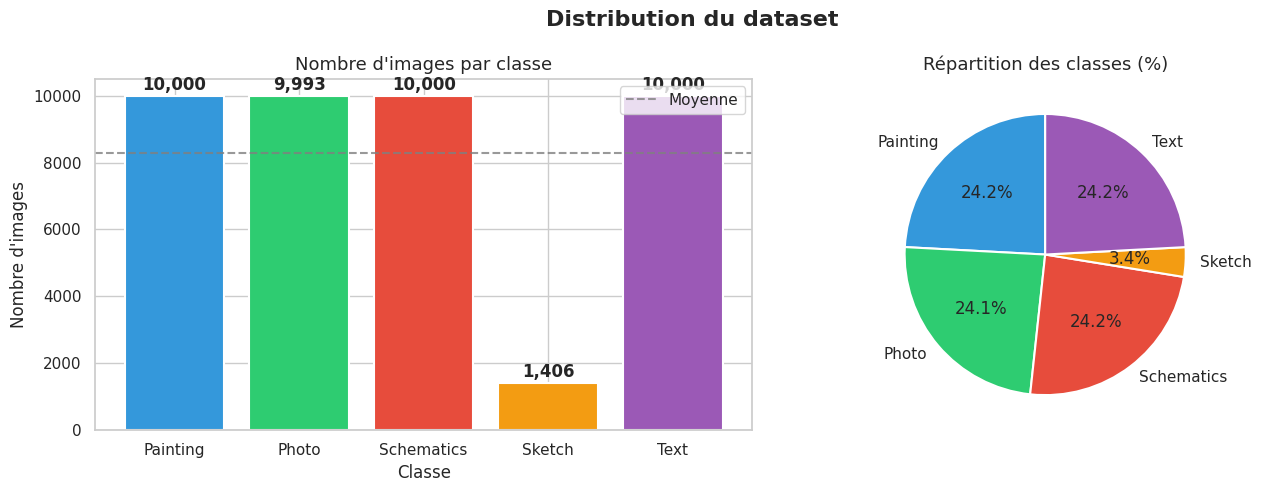


Classe            Images       %
---------------------------------
Painting          10,000   24.2%
Photo              9,993   24.1%
Schematics        10,000   24.2%
Sketch             1,406    3.4% ⚠️
Text              10,000   24.2%
---------------------------------
TOTAL             41,399  100.0%

Ratio max/min : 7.1x — déséquilibre significatif (Sketch sous-représentée). Class weights nécessaires.


In [4]:
# ============================================================
# DISTRIBUTION DES CLASSES
# ============================================================

# Comptage des images pour chaque classe
class_counts = {}
for class_name in CLASS_NAMES:
    class_path = os.path.join(DATA_DIR, class_name)
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    class_counts[class_name] = len(images)

total = sum(class_counts.values())

# Visualisation en deux graphiques complémentaires
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution du dataset', fontsize=16, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

# -- Histogramme : permet de voir les valeurs absolues et l'écart entre classes --
bars = ax1.bar(class_counts.keys(), class_counts.values(), color=colors,
               edgecolor='white', linewidth=1.5)
ax1.axhline(total / NUM_CLASSES, color='gray', linestyle='--', alpha=0.8, label='Moyenne')
ax1.set_title("Nombre d'images par classe", fontsize=13)
ax1.set_xlabel('Classe')
ax1.set_ylabel("Nombre d'images")
ax1.legend()
for bar, cnt in zip(bars, class_counts.values()):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 60,
             f'{cnt:,}', ha='center', va='bottom', fontweight='bold')

# -- Camembert : proportions relatives --
ax2.pie(class_counts.values(), labels=class_counts.keys(), colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Répartition des classes (%)', fontsize=13)

plt.tight_layout()
plt.show()

# Tableau récapitulatif
print(f"\n{'Classe':<15} {'Images':>8} {'%':>7}")
print("-" * 33)
for cls, cnt in class_counts.items():
    flag = ' ' if cnt < total / NUM_CLASSES * 0.5 else ''
    print(f"{cls:<15} {cnt:>8,} {cnt/total*100:>6.1f}%{flag}")
print("-" * 33)
print(f"{'TOTAL':<15} {total:>8,} {'100.0%':>7}")

min_cls = min(class_counts, key=class_counts.get)
max_cls = max(class_counts, key=class_counts.get)
ratio   = class_counts[max_cls] / class_counts[min_cls]
print(f"\nRatio max/min : {ratio:.1f}x — ", end="")
if ratio > 3:
    print(f"déséquilibre significatif ({min_cls} sous-représentée). Class weights nécessaires.")
else:
    print("déséquilibre modéré, gérable.")

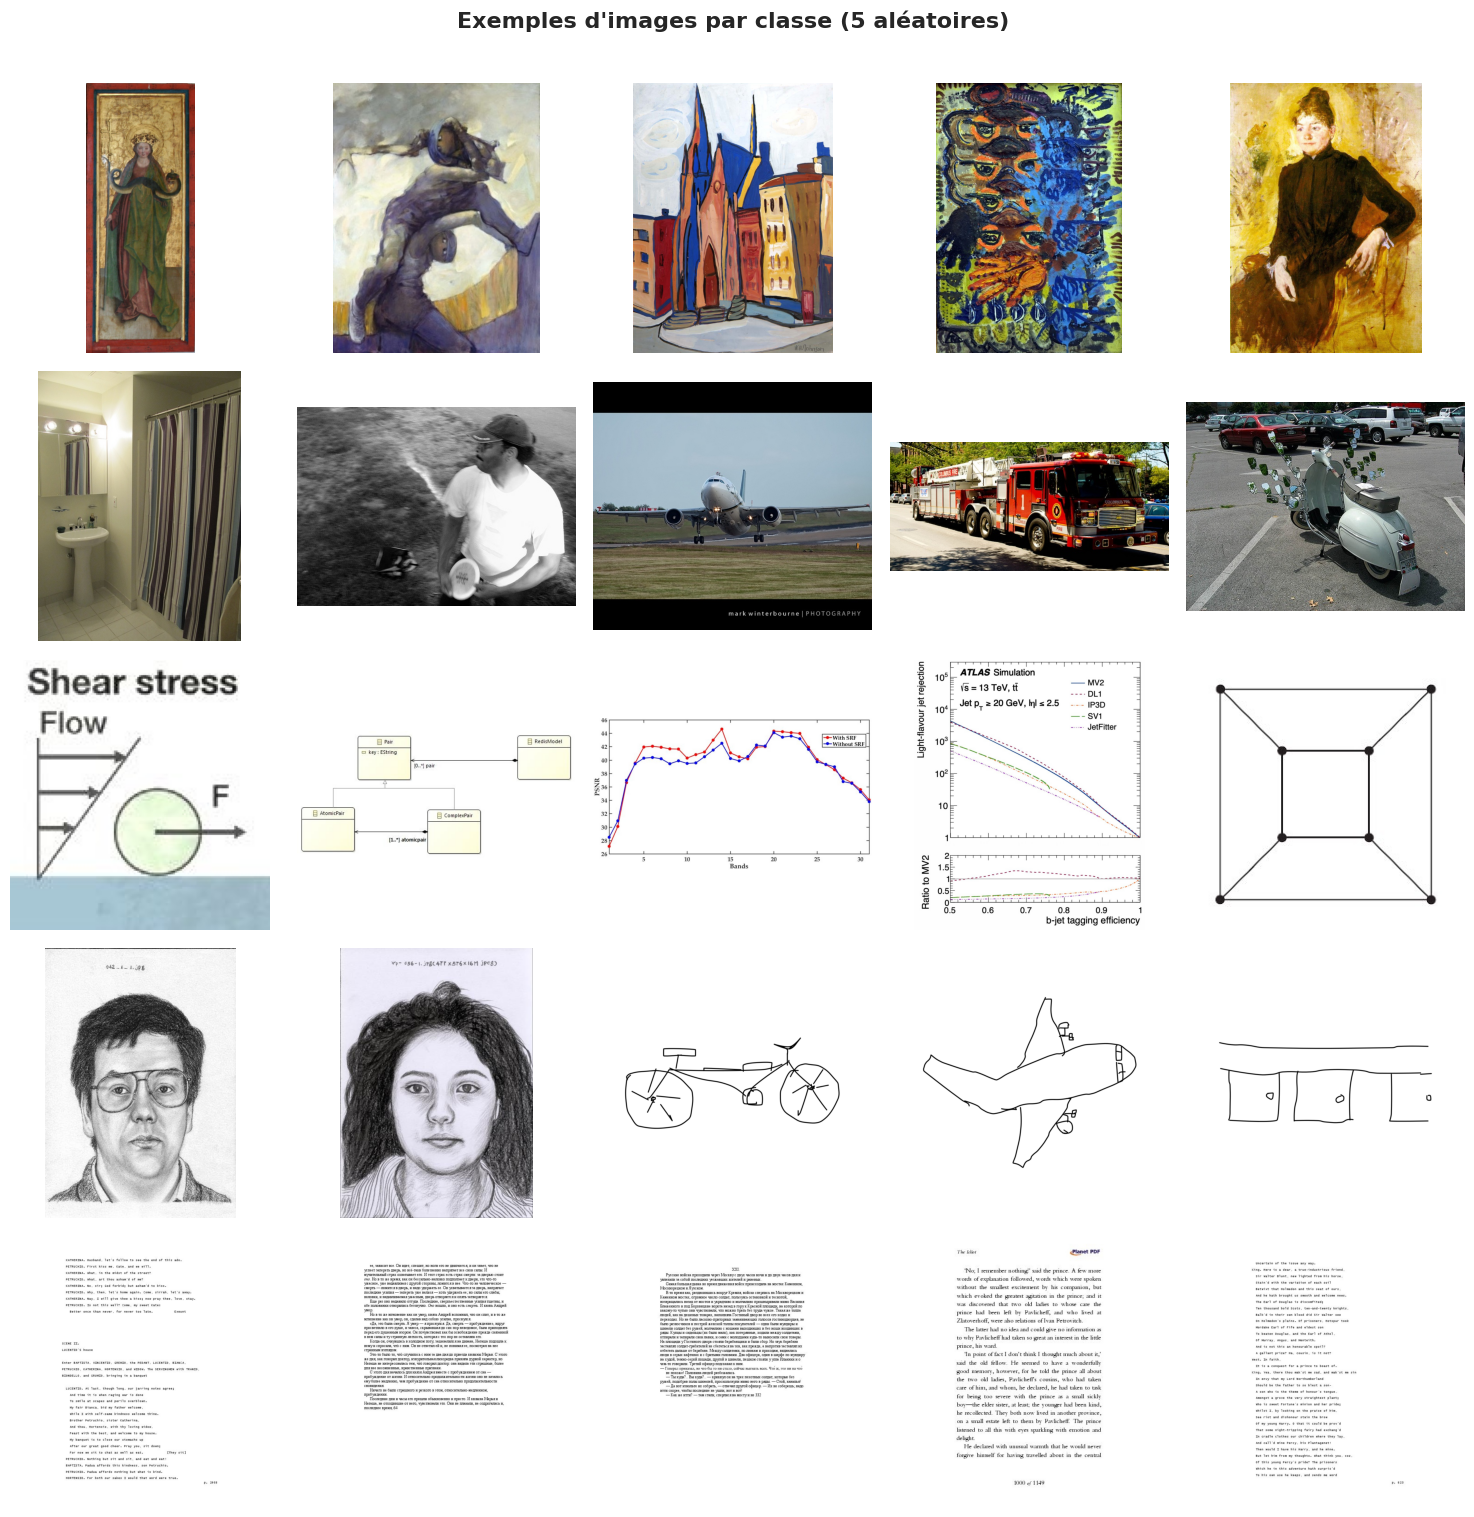

In [5]:
# ============================================================
# EXEMPLES VISUELS PAR CLASSE
# Visualiser quelques images par classe permet de comprendre
# la difficulté de la tâche (ex : peinture réaliste vs photo).
# ============================================================

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 3 * NUM_CLASSES))
fig.suptitle("Exemples d'images par classe (5 aléatoires)",
             fontsize=16, fontweight='bold', y=1.01)

for i, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(DATA_DIR, class_name)
    all_files  = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    # Sélection reproductible de 5 images
    sample_files = np.random.choice(all_files, min(5, len(all_files)), replace=False)

    for j, img_name in enumerate(sample_files):
        img = tf.keras.utils.load_img(os.path.join(class_path, img_name))
        axes[i, j].imshow(np.array(img))
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(class_name, fontsize=12, fontweight='bold',
                                   rotation=0, labelpad=70, ha='right')

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# ANALYSE DES DIMENSIONS (échantillon de 30 images/classe)
# Utile pour choisir la taille de redimensionnement.
# ============================================================

print("Analyse des dimensions d'un échantillon d'images...\n")

records = []
for class_name in CLASS_NAMES:
    class_path = os.path.join(DATA_DIR, class_name)
    all_files  = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample     = np.random.choice(all_files, min(30, len(all_files)), replace=False)
    for img_name in sample:
        img = tf.keras.utils.load_img(os.path.join(class_path, img_name))
        w, h = img.size
        records.append({'Classe': class_name, 'Largeur': w, 'Hauteur': h, 'Ratio': w / h})

df_dims = pd.DataFrame(records)

print("Statistiques globales des dimensions (pixels) :")
print(df_dims[['Largeur', 'Hauteur']].describe().round(0).astype(int).to_string())
print(f"\nRatio largeur/hauteur médian : {df_dims['Ratio'].median():.2f}")
print(f"\n  Les images seront redimensionnées en {IMG_SIZE[0]}×{IMG_SIZE[1]} pixels.")
print("    Ce format réduit la mémoire et uniformise les entrées du réseau.")

Analyse des dimensions d'un échantillon d'images...

Statistiques globales des dimensions (pixels) :
       Largeur  Hauteur
count      150      150
mean       794      757
std        538      529
min         75       76
25%        562      496
50%        640      644
75%        932      842
max       3701     5490

Ratio largeur/hauteur médian : 1.00

➡️  Les images seront redimensionnées en 128×128 pixels.
    Ce format réduit la mémoire et uniformise les entrées du réseau.


---
## 1b. Nettoyage des Images Corrompues

Certaines images ont des métadonnées JPEG/PNG malformées que le décodeur TensorFlow (strict) rejette.

**Stratégie :**
1. PIL ouvre chaque image avec `LOAD_TRUNCATED_IMAGES = True` (plus tolérant que TF)
2. Si PIL réussit → re-sauvegarde en RGB propre (supprime les métadonnées corrompues)
3. Si PIL échoue → image irrécupérable, déplacée dans `data/_corrupt/`

> Un fichier `.images_cleaned` est créé après le passage pour éviter de tout re-scanner à chaque exécution.

In [7]:
# ============================================================
# NETTOYAGE DES IMAGES CORROMPUES
# ============================================================

from PIL import Image, ImageFile
import shutil
from tqdm.notebook import tqdm

FLAG_FILE = '.images_cleaned'

if os.path.exists(FLAG_FILE):
    print("Images déjà nettoyées (flag .images_cleaned présent). Étape ignorée.")
    print("Supprimez ce fichier pour relancer le nettoyage.")
else:
    # PIL tolérant : peut lire les JPEG tronqués que TF refuse
    ImageFile.LOAD_TRUNCATED_IMAGES = True

    corrupt_dir = os.path.join(DATA_DIR, '_corrupt')
    os.makedirs(corrupt_dir, exist_ok=True)

    # Collecte de tous les fichiers image
    all_files = []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(DATA_DIR, cls)
        for f in sorted(os.listdir(cls_dir)):
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                all_files.append(os.path.join(cls_dir, f))

    n_ok = n_fixed = n_corrupt = 0

    for img_path in tqdm(all_files, desc="Nettoyage", unit="img"):
        try:
            with Image.open(img_path) as img:
                img.load()          # Force le décodage complet
                rgb = img.convert('RGB')

            # Re-sauvegarde propre : supprime les métadonnées corrompues
            ext = os.path.splitext(img_path)[1].lower()
            fmt = 'JPEG' if ext in ('.jpg', '.jpeg') else 'PNG'
            rgb.save(img_path, format=fmt, quality=95)
            n_fixed += 1

        except Exception:
            # PIL ne peut pas du tout ouvrir cette image → irrécupérable
            dest = os.path.join(corrupt_dir, os.path.basename(img_path))
            shutil.move(img_path, dest)
            n_corrupt += 1

    # Flag pour éviter de relancer à chaque exécution
    open(FLAG_FILE, 'w').close()

    print(f"\n Images re-sauvegardées proprement : {n_fixed:,}")
    print(f" Images irrécupérables (déplacées vers {corrupt_dir}) : {n_corrupt}")
    if n_corrupt > 0:
        print("   → Ces images sont exclues du dataset automatiquement.")
    print("\nRelancez les cellules de chargement du dataset (cell-load-data) maintenant.")

Images déjà nettoyées (flag .images_cleaned présent). Étape ignorée.
Supprimez ce fichier pour relancer le nettoyage.


---
## 2. Preparation des Donnees <a id="2"></a>

### Objectif : Photo ou Pas une Photo ?

La tache est une **classification binaire** : l'image est-elle une photographie reelle,
ou appartient-elle a une autre categorie (Painting, Schematics, Sketch, Text) ?

- **Label 1** -- Photo
- **Label 0** -- Pas une Photo (toutes les autres classes regroupees)

### Strategie de chargement

- **Chargement par batches** avec `image_dataset_from_directory` -- evite de charger ~41 000 images en RAM d'un coup
- **Redimensionnement** a 128x128 px (compromis qualite/vitesse)
- **Normalisation** des pixels `[0, 255]` vers `[0, 1]` (necessaire pour la convergence du reseau)
- **Augmentation** sur le train uniquement (enrichit artificiellement les donnees)
- **Class weights** pour compenser le desequilibre Photo / Non-Photo

### Decoupage train / val / test

```
Dataset complet (~41 399 images)
         |
    +----+----+
   80%       20%
  Train   Val + Test
             |
          +--+--+
         50%   50%
         Val   Test
        (~10%) (~10%)
```

> **Pourquoi un set de test separe ?**  
> La validation sert a guider l'entrainement (early stopping, lr scheduling).  
> Le test, jamais vu pendant l'entrainement, donne une mesure **non biaisee** des performances reelles.


In [5]:
# ============================================================
# CHARGEMENT DU DATASET
#
# shuffle=True sur les deux appels est indispensable : sans ça,
# les fichiers sont triés alphabétiquement par classe, et
# take(n_val) ne prendrait que les premières classes (Painting,
# Photo) → val_accuracy = 0%.
# Avec seed=42, le split est reproductible et complémentaire.
# ============================================================

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
)

val_test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True,
)

print(f"Classes détectées par TF : {train_ds_raw.class_names}")

n_val_test = tf.data.experimental.cardinality(val_test_ds_raw).numpy()
n_val      = n_val_test // 2
val_ds_raw  = val_test_ds_raw.take(n_val)
test_ds_raw = val_test_ds_raw.skip(n_val)

n_train = tf.data.experimental.cardinality(train_ds_raw).numpy()
n_test  = n_val_test - n_val
print(f"\nBatches  — Train: {n_train} | Val: {n_val} | Test: {n_test}")
print(f"Images ~  — Train: {n_train*BATCH_SIZE:,} | Val: {n_val*BATCH_SIZE:,} | Test: {n_test*BATCH_SIZE:,}")

Found 41402 files belonging to 5 classes.
Using 33122 files for training.


2026-05-28 06:51:15.759047: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-28 06:51:15.759148: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-28 06:51:15.759164: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-28 06:51:16.706574: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-28 06:51:16.706622: I tensorflow/compile

Found 41402 files belonging to 5 classes.
Using 8280 files for validation.
Classes détectées par TF : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']

Batches  — Train: 1036 | Val: 129 | Test: 130
Images ~  — Train: 33,152 | Val: 4,128 | Test: 4,160


In [ ]:
# ============================================================
# AUGMENTATION DES DONNÉES
# On l'applique UNIQUEMENT sur le set d'entraînement.
#
# Pas de ignore_errors() ici : le nettoyage PIL (cell 07cc88e5)
# a déjà corrigé ou écarté les images corrompues. Sans ignore_errors(),
# la cardinalité du dataset reste CONNUE, ce qui permet à Keras
# d'afficher la progression XX/YY et de recréer l'itérateur
# naturellement à chaque epoch — exactement comme dans le WS.
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.15),
], name="data_augmentation")

rescale  = layers.Rescaling(1.0 / 255.0)
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(images, labels):
    images = data_augmentation(images, training=True)
    images = rescale(images)
    return images, labels

def preprocess_eval(images, labels):
    images = rescale(images)
    return images, labels

# Pipeline sans ignore_errors() ni repeat() :
# Keras itère chaque dataset jusqu'à StopIteration (fin naturelle de l'epoch),
# puis recrée un nouvel itérateur pour l'epoch suivante.
train_ds = (train_ds_raw
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

val_ds = (val_ds_raw
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

test_ds = (test_ds_raw
    .map(preprocess_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

print("Pipeline configuré :")
print("  train_ds  → augmentation + normalisation")
print("  val_ds    → normalisation")
print("  test_ds   → normalisation")
# ============================================================
# REMAPPING BINAIRE : Photo=1, tout le reste=0
# ============================================================
# CLASS_NAMES alphabetique : Painting=0, Photo=1, Schematics=2, Sketch=3, Text=4
# On unifie tout sauf Photo sous le label 0 (Pas une Photo)
# ============================================================

def to_binary(x, y):
    return x, tf.cast(tf.equal(y, PHOTO_CLASS_IDX), tf.int32)

train_ds = train_ds.map(to_binary, num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(to_binary,   num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(to_binary,  num_parallel_calls=AUTOTUNE)

print('Remapping binaire applique :')
print(f'  Photo (idx {PHOTO_CLASS_IDX}) -> label 1')
print( '  Tout autre           -> label 0 (Pas une Photo)')


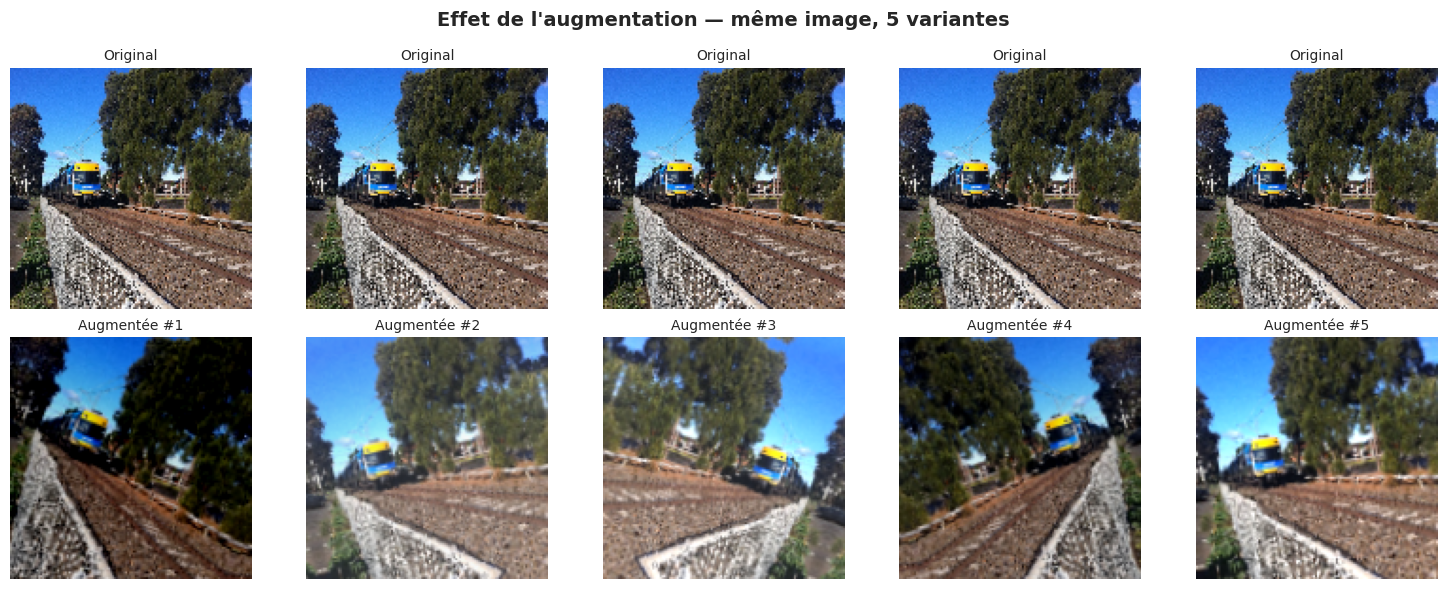

In [10]:
# ============================================================
# VISUALISATION DE L'AUGMENTATION
# On applique l'augmentation sur la même image plusieurs fois
# pour voir la diversité générée.
# ============================================================

# Récupère une image de la classe Photo
photo_dir    = os.path.join(DATA_DIR, 'Photo')
sample_file  = os.listdir(photo_dir)[0]
sample_img   = tf.keras.utils.load_img(os.path.join(photo_dir, sample_file), target_size=IMG_SIZE)
# img_to_array retourne déjà un numpy.ndarray — pas besoin de .numpy()
sample_arr   = tf.keras.utils.img_to_array(sample_img)   # shape (128,128,3), valeurs [0,255]
sample_batch = tf.expand_dims(sample_arr, 0)              # tensor (1,128,128,3) pour le pipeline

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Effet de l'augmentation — même image, 5 variantes",
             fontsize=14, fontweight='bold')

# Ligne 1 : originale (répétée) — sample_arr est un ndarray, .astype suffit
for j in range(5):
    axes[0, j].imshow(sample_arr.astype('uint8'))
    axes[0, j].axis('off')
    axes[0, j].set_title('Original', fontsize=10)

# Ligne 2 : versions augmentées — le résultat de data_augmentation est un tensor TF
for j in range(5):
    aug = data_augmentation(sample_batch, training=True)[0]
    aug = tf.clip_by_value(aug, 0, 255).numpy().astype('uint8')
    axes[1, j].imshow(aug)
    axes[1, j].axis('off')
    axes[1, j].set_title(f'Augmentée #{j+1}', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CLASS WEIGHTS — CLASSIFICATION BINAIRE
# ============================================================
# Les poids compensent le desequilibre entre Photo et Non-Photo.
# label 0 = Pas une Photo  (Painting + Schematics + Sketch + Text)
# label 1 = Photo
# ============================================================

from tqdm.notebook import tqdm

# Comptage des 5 classes brutes (avant remapping)
label_counts = {}
for cls in CLASS_NAMES:
    label_counts[cls] = 0

import os as _os
for cls in CLASS_NAMES:
    cls_dir = _os.path.join(DATA_DIR, cls)
    if _os.path.isdir(cls_dir):
        label_counts[cls] = len([f for f in _os.listdir(cls_dir)
                                  if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))])

n_photo     = label_counts.get('Photo', 0)
n_not_photo = sum(v for k, v in label_counts.items() if k != 'Photo')
n_total     = n_photo + n_not_photo

# Poids inverses de la frequence
class_weights = {
    0: n_total / (2.0 * n_not_photo) if n_not_photo > 0 else 1.0,
    1: n_total / (2.0 * n_photo)     if n_photo     > 0 else 1.0,
}

print(f"Distribution binaire sur {n_total:,} images :")
print(f"  label 0 = Pas une Photo : {n_not_photo:,} images  (poids {class_weights[0]:.3f})")
print(f"  label 1 = Photo         : {n_photo:,} images  (poids {class_weights[1]:.3f})")
print(f"\nRatio Photo / Total : {n_photo/n_total*100:.1f}%")


---
## 3. Architecture du Reseau de Neurones <a id="3"></a>

### Pourquoi un CNN ?

Les **Reseaux de Neurones Convolutifs (CNN)** sont l'architecture de reference pour la classification d'images :
- Les **filtres de convolution** detectent automatiquement des caracteristiques spatiales (bords, textures, formes)
- Le **partage des poids** rend le modele efficace en parametres
- L'**invariance a la translation** (via MaxPooling) ameliore la generalisation

### Architecture choisie -- CNN binaire a 4 blocs convolutifs

Inspiree de VGGNet, notre architecture empile des blocs `Conv -> BatchNorm -> ReLU -> MaxPool -> Dropout`,
avec une profondeur croissante des filtres (32 -> 64 -> 128 -> 256) :

```
INPUT  (128 x 128 x 3)
  |
  +-> BLOC 1 --- Conv2D(32) x 2 -> BN -> ReLU -> MaxPool(2x2) -> Drop(0.25)
  |              Sortie : 64 x 64 x 32   -- detection : bords, gradients de couleur
  |
  +-> BLOC 2 --- Conv2D(64) x 2 -> BN -> ReLU -> MaxPool(2x2) -> Drop(0.25)
  |              Sortie : 32 x 32 x 64   -- detection : textures, motifs locaux
  |
  +-> BLOC 3 --- Conv2D(128) x 2 -> BN -> ReLU -> MaxPool(2x2) -> Drop(0.25)
  |              Sortie : 16 x 16 x 128  -- detection : formes complexes
  |
  +-> BLOC 4 --- Conv2D(256) -> BN -> ReLU -> MaxPool(2x2) -> Drop(0.25)
  |              Sortie : 8 x 8 x 256    -- semantique globale
  |
  +-> GlobalAveragePooling2D  ->  1 x 256
  |
  +-> Dense(512) -> BN -> ReLU -> Dropout(0.5)
  |
  +-> Dense(1, sigmoid)  ->  P(Photo) dans [0, 1]
           |
       >= 0.5 -> Photo   |   < 0.5 -> Pas une Photo
```

### Justification des composants

| Composant | Role |
|-----------|------|
| **Conv2D** | Extraction de features par filtres apprenants |
| **BatchNormalization** | Stabilise l'entrainement, accelere la convergence |
| **ReLU** | Introduit la non-linearite (sans saturer le gradient) |
| **MaxPooling2D** | Reduit la resolution, renforce l'invariance |
| **Dropout** | Regularisation -- force le reseau a ne pas dependre de neurones specifiques |
| **GlobalAveragePooling** | Alternative plus legere au Flatten -- reduit le risque de surapprentissage |
| **Sigmoid** | Sortie dans [0,1] interpretable directement comme P(Photo) |

### Pourquoi sigmoid et non softmax ?

Avec 2 classes, un seul neurone sigmoid suffit : P(Pas Photo) = 1 - P(Photo).  
Softmax necessiterait 2 neurones, ce qui est equivalent mais plus lourd.  
La loss associee est `binary_crossentropy` (vs `categorical_crossentropy` pour le multiclasse).


In [ ]:
# ============================================================
# CONSTRUCTION DU CNN — CLASSIFICATION BINAIRE
# ============================================================
# Differences vs multiclasse :
#   - Couche de sortie : Dense(1, sigmoid) au lieu de Dense(5, softmax)
#   - sigmoid : retourne P(Photo) dans [0, 1]
#   - Loss : binary_crossentropy (plus adaptee que categorical)
#
# Architecture 4 blocs inchangee :
#   Bloc1 (32) → Bloc2 (64) → Bloc3 (128) → Bloc4 (256) → GAP → Dense(512) → Dense(1)
# ============================================================

def build_cnn_binary(input_shape=(128, 128, 3), dropout_conv=0.25, dropout_dense=0.5):
    """
    CNN 4 blocs pour classification binaire Photo / Pas une Photo.
    Sortie : 1 neurone sigmoid -> P(Photo).
    """
    m = models.Sequential(name='CNN_TouNum_Binaire')
    m.add(layers.Input(shape=input_shape))

    # Bloc 1 : bords et gradients (32 filtres)
    for _ in range(2):
        m.add(layers.Conv2D(32,  (3, 3), padding='same'))
        m.add(layers.BatchNormalization())
        m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Dropout(dropout_conv))

    # Bloc 2 : textures (64 filtres)
    for _ in range(2):
        m.add(layers.Conv2D(64,  (3, 3), padding='same'))
        m.add(layers.BatchNormalization())
        m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Dropout(dropout_conv))

    # Bloc 3 : formes complexes (128 filtres)
    for _ in range(2):
        m.add(layers.Conv2D(128, (3, 3), padding='same'))
        m.add(layers.BatchNormalization())
        m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Dropout(dropout_conv))

    # Bloc 4 : representations semantiques (256 filtres)
    m.add(layers.Conv2D(256, (3, 3), padding='same'))
    m.add(layers.BatchNormalization())
    m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Dropout(dropout_conv))

    # Classifieur
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dense(512))
    m.add(layers.BatchNormalization())
    m.add(layers.Activation('relu'))
    m.add(layers.Dropout(dropout_dense))

    # Sortie binaire : 1 neurone sigmoid -> P(Photo in [0,1])
    m.add(layers.Dense(1, activation='sigmoid', name='photo_probability'))

    return m


model = build_cnn_binary(input_shape=(*IMG_SIZE, 3))
model.summary()


In [ ]:
# ============================================================
# COMPILATION — CLASSIFICATION BINAIRE
# ============================================================
# Loss : binary_crossentropy
#   Mesuree la distance entre P(Photo) predit et la vraie etiquette 0/1.
#   Equivalente a la cross-entropie categorique avec 2 classes.
#
# Metriques :
#   accuracy  : taux de bonne classification global
#   AUC       : aire sous la courbe ROC (independant du seuil 0.5)
#   Precision : vrais positifs / tous les positifs predits
#   Recall    : vrais positifs / tous les vrais positifs reels
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ],
)

# Verification : passage d'un batch fictif
dummy = tf.zeros((1, *IMG_SIZE, 3))
out   = model(dummy, training=False)
print(f'Sortie du modele : shape={out.shape}  valeur={out.numpy()[0,0]:.4f} (P(Photo))')
print(f'Interpretation   : 0.0 = certainement PAS une Photo | 1.0 = certainement une Photo')


---
## 4. Entraînement <a id="4"></a>

### Stratégie d'optimisation

L'entraînement utilise l'optimiseur **Adam** (Adaptive Moment Estimation), qui adapte
automatiquement le taux d'apprentissage pour chaque paramètre. C'est le choix standard
pour les CNN car il converge rapidement et tolère bien des hyperparamètres non parfaits.

### Callbacks

Trois mécanismes automatiques pilotent et sécurisent l'entraînement :

| Callback | Paramètres | Rôle |
|----------|-----------|------|
| **EarlyStopping** | `patience=8` | Arrête si `val_loss` ne baisse plus pendant 8 epochs consécutives. Restaure automatiquement les poids du meilleur epoch. |
| **ReduceLROnPlateau** | `patience=3`, `factor=0.5` | Divise le learning rate par 2 après 3 epochs sans amélioration. Affine la convergence quand le modèle est proche de l'optimum. |
| **ModelCheckpoint** | `monitor=val_accuracy` | Sauvegarde le modèle **uniquement** quand `val_accuracy` s'améliore — garantit de conserver le meilleur état. |

### Pourquoi ces valeurs ?

- **patience=8** pour EarlyStopping : suffisamment tolérant pour que ReduceLROnPlateau ait le temps de réduire le LR et relancer la descente.
- **patience=3** pour ReduceLR : déclenche tôt pour ne pas gaspiller d'epochs à un LR trop élevé.
- **factor=0.5** : diviser par 2 est un compromis — pas trop agressif (÷10) ni trop timide (÷1.1).

### Mécanisme anti-surapprentissage intégré

```
Epoch k : val_loss diminue → continue
Epoch k+1..k+3 : val_loss stagne → ReduceLR divise le LR par 2
Epoch k+4..k+8 : val_loss stagne encore → EarlyStopping déclenche
→ Les meilleurs poids (epoch k) sont restaurés automatiquement
```


In [14]:
# ============================================================
# CALLBACKS
# ============================================================

callbacks = [
    # Arrête l'entraînement si val_loss ne baisse plus pendant 8 epochs
    # → laisse le temps à ReduceLROnPlateau d'agir (patience=3) avant de stopper
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),

    # save_format='h5' forcé explicitement — le format .keras natif de TF 2.14
    # passe un argument 'options' non supporté et lève une ValueError
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_format='h5',
        verbose=1,
    ),
]

print("Callbacks configurés :")
for cb in callbacks:
    print(f"  - {cb.__class__.__name__}")
print(f"  Modèle sauvegardé dans : {MODEL_SAVE_PATH}")

Callbacks configurés :
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint
  Modèle sauvegardé dans : ./model_classification.h5


In [15]:
# ============================================================
# ENTRAÎNEMENT
#
# Pas de steps_per_epoch ni validation_steps : Keras itère
# chaque dataset jusqu'à épuisement naturel (comme dans le WS).
# La cardinalité est connue → progression XX/YY affichée.
# ============================================================

print("Début de l'entraînement...")
print(f"  Taille image   : {IMG_SIZE}")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Epochs max     : {EPOCHS}")
print(f"  Learning rate  : {LEARNING_RATE}")
print("-" * 50)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEntraînement terminé. Meilleur modèle sauvegardé : {MODEL_SAVE_PATH}")

Début de l'entraînement...
  Taille image   : (128, 128)
  Batch size     : 32
  Epochs max     : 30
  Learning rate  : 0.0001
--------------------------------------------------
Epoch 1/30


2026-05-26 12:18:26.497828: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inCNN_TouNum/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1035/1035 [==============================] - ETA: 0s - loss: 0.2302 - accuracy: 0.8933
Epoch 1: val_accuracy improved from -inf to 0.81516, saving model to ./model_classification.h5
1035/1035 [==============================] - 112s 101ms/step - loss: 0.2302 - accuracy: 0.8933 - val_loss: 0.5017 - val_accuracy: 0.8152 - lr: 2.5000e-05
Epoch 2/30
1035/1035 [==============================] - ETA: 0s - loss: 0.2288 - accuracy: 0.8946
Epoch 2: val_accuracy did not improve from 0.81516
1035/1035 [==============================] - 100s 96ms/step - loss: 0.2288 - accuracy: 0.8946 - val_loss: 0.4974 - val_accuracy: 0.8127 - lr: 2.5000e-05
Epoch 3/30
1035/1035 [==============================] - ETA: 0s - loss: 0.2226 - accuracy: 0.8973
Epoch 3: val_accuracy improved from 0.81516 to 0.83915, saving model to ./model_classification.h5
1035/1035 [==============================] - 105s 101ms/step - loss: 0.2226 - accuracy: 0.8973 - val_loss: 0.4390 - val_accuracy: 0.8391 - lr: 2.5000e-05
Epoch 4/30
1

---
## 5. Analyse des Resultats <a id="5"></a>

### Courbes d'apprentissage

Les courbes **train vs validation** sont l'outil principal pour diagnostiquer l'etat de l'apprentissage.
On les lit en cherchant trois patterns :

```
  Accuracy
     |
  1  +-- train  ------------------
     |   val    -----------------   <- Bon equilibre : courbes proches et hautes
     |
     |   train  ------------------
     |   val    --------           <- Surapprentissage : ecart croissant
     |
     |   train  ------
     |   val    ------             <- Sous-apprentissage : les deux sont basses
     |
  0  +----------------------------> Epochs
```

### Metriques specifiques a la classification binaire

| Metrique | Formule | Interpretation |
|----------|---------|---------------|
| **Accuracy** | (TP+TN) / N | Taux global de bonne classification |
| **AUC-ROC** | Aire sous la courbe ROC | Discriminabilite independante du seuil -- 1.0 = parfait, 0.5 = aleatoire |
| **Precision** | TP / (TP + FP) | Parmi les images predites Photo, combien le sont vraiment ? |
| **Rappel** | TP / (TP + FN) | Parmi les vraies Photos, combien sont detectees ? |
| **F1-score** | 2 x P x R / (P + R) | Equilibre precision/rappel -- utile si classes desequilibrees |

### Matrice de confusion binaire 2x2

```
                  Predit
                  +--------------+------------+
                  | Pas une Photo|   Photo    |
         +--------+--------------+------------+
  Reel   |Pas Photo|   TN        |    FP      |
         +--------+--------------+------------+
         |  Photo |   FN        |    TP      |
         +--------+--------------+------------+
```

- **TN** : Non-photo correctement rejetee
- **TP** : Photo correctement detectee
- **FP** : Fausse alarme -- non-photo classee Photo
- **FN** : Photo manquee -- non detectee


---
### Reprise après restart du kernel

> **Note :** Si le kernel a été redémarré (arrêt du conteneur Docker, fermeture du navigateur, etc.),
> les variables Python sont perdues mais le modèle sauvegardé sur disque persiste.
> La cellule ci-dessous recharge le modèle directement depuis `model_classification.h5`
> — inutile de ré-entraîner.


In [ ]:
# ============================================================
# REPRISE RAPIDE — après un restart du container Docker
#
# Le kernel Python repart à zéro : les variables (model, history,
# train_ds…) sont perdues. Mais model_classification.h5 est sur
# le volume Docker → il persiste entre les sessions.
#
# Pour évaluer/utiliser le modèle sans ré-entraîner, exécutez
# dans l'ordre :
#   1. cell-imports      (imports)
#   2. cell-config       (chemins, CLASS_NAMES, IMG_SIZE…)
#   3. cell-load-data    (reconstruction des datasets)
#   4. cell-augmentation (reconstruction des pipelines)
#   5. CETTE cellule     (chargement du modèle sauvegardé)
#   6. cell-eval / cell-confusion / cell-gui  (analyses)
#
# Note : cell-curves nécessite l'objet `history` qui n'existe
# qu'après un vrai entraînement — elle ne peut pas être relancée
# après restart sans re-lancer cell-fit.
# ============================================================

if os.path.exists(MODEL_SAVE_PATH):
    model = keras.models.load_model(MODEL_SAVE_PATH)
    print(f"Modèle chargé depuis : {MODEL_SAVE_PATH}")
    print(f"Architecture : {model.input_shape} → {model.output_shape}")
else:
    print(f"Aucun modèle trouvé à '{MODEL_SAVE_PATH}'.")
    print("Relancez l'entraînement complet (cell-build-model → cell-compile → cell-fit).")

Modèle chargé depuis : ./model_classification.h5
Architecture : (None, 128, 128, 3) → (None, 5)


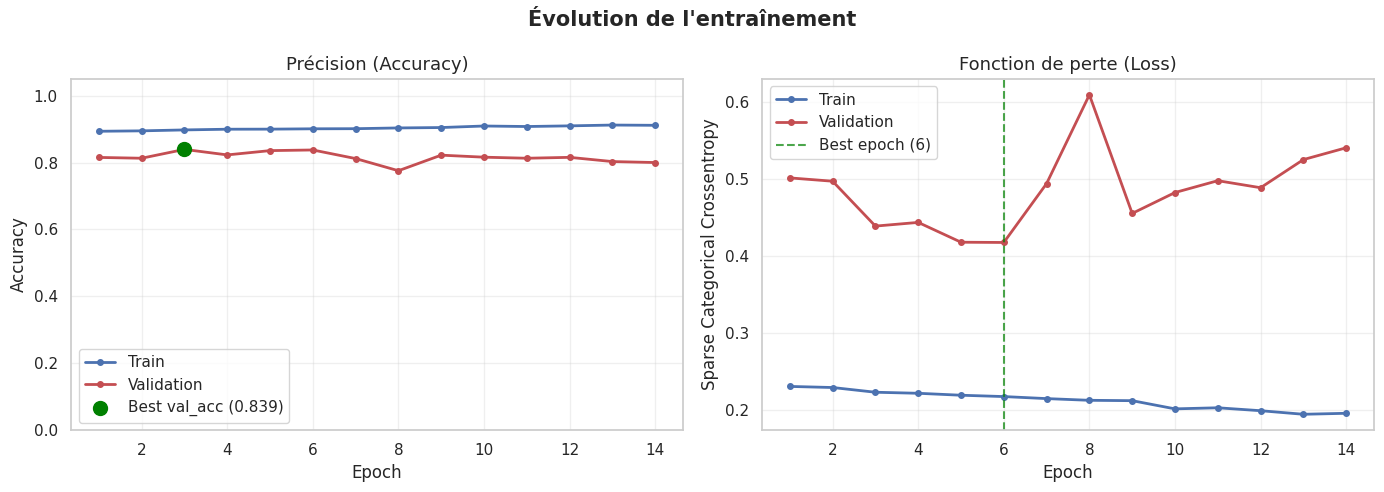


📊 Résumé :
  Epochs effectuées  : 14
  Meilleure val_acc  : 0.8391 (83.91%) à l'epoch 3
  Dernière train_acc : 0.9111
  Dernière val_acc   : 0.7999
  Écart train/val    : 0.1112  → ✅ Apprentissage stable


In [16]:
# ============================================================
# COURBES D'ENTRAÎNEMENT
# ============================================================

def plot_history(history):
    """Affiche les courbes loss et accuracy (train vs validation)."""
    epochs_ran = range(1, len(history.history['loss']) + 1)

    fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Évolution de l'entraînement", fontsize=15, fontweight='bold')

    # -- Courbe Accuracy --
    ax2.plot(epochs_ran, history.history['accuracy'],     'b-o', ms=4, lw=2, label='Train')
    ax2.plot(epochs_ran, history.history['val_accuracy'], 'r-o', ms=4, lw=2, label='Validation')
    best_acc_epoch = int(np.argmax(history.history['val_accuracy'])) + 1
    best_acc       = max(history.history['val_accuracy'])
    ax2.scatter([best_acc_epoch], [best_acc], color='green', zorder=5, s=100,
                label=f'Best val_acc ({best_acc:.3f})')
    ax2.set_title('Précision (Accuracy)', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # -- Courbe Loss --
    ax1.plot(epochs_ran, history.history['loss'],     'b-o', ms=4, lw=2, label='Train')
    ax1.plot(epochs_ran, history.history['val_loss'], 'r-o', ms=4, lw=2, label='Validation')
    best_epoch = int(np.argmin(history.history['val_loss'])) + 1
    ax1.axvline(best_epoch, color='green', ls='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
    ax1.set_title('Fonction de perte (Loss)', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Sparse Categorical Crossentropy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()

    # Résumé chiffré
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc   = history.history['val_accuracy'][-1]
    gap             = final_train_acc - final_val_acc

    print(f"\n📊 Résumé :")
    print(f"  Epochs effectuées  : {len(epochs_ran)}")
    print(f"  Meilleure val_acc  : {best_acc:.4f} ({best_acc*100:.2f}%) à l'epoch {best_acc_epoch}")
    print(f"  Dernière train_acc : {final_train_acc:.4f}")
    print(f"  Dernière val_acc   : {final_val_acc:.4f}")
    print(f"  Écart train/val    : {gap:.4f}", end="  ")
    if gap > 0.15:
        print("→   Surapprentissage probable")
    elif final_val_acc < 0.70:
        print("→   Sous-apprentissage probable")
    else:
        print("→  Apprentissage stable")


plot_history(history)

In [ ]:
# ============================================================
# EVALUATION FINALE — CLASSIFICATION BINAIRE
# ============================================================

import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt

y_true_all = []
y_prob_all = []

for x_batch, y_batch in test_ds:
    probs = model.predict(x_batch, verbose=0)[:, 0]  # P(Photo)
    y_prob_all.extend(probs.tolist())
    y_true_all.extend(y_batch.numpy().tolist())

y_true = np.array(y_true_all, dtype=int)
y_prob = np.array(y_prob_all)
y_pred = (y_prob >= 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
auc  = roc_auc_score(y_true, y_prob)

print('=' * 55)
print('RESULTATS — Notre CNN Binaire (set de test)')
print('=' * 55)
print(f'  Accuracy   : {acc*100:.2f}%   (global)')
print(f'  AUC        : {auc:.4f}   (robuste au seuil)')
print(f'  Precision  : {prec*100:.2f}%   (parmi pred. Photo, vrais Photos)')
print(f'  Recall     : {rec*100:.2f}%   (Photos reelles detectees)')
print(f'  F1 Score   : {f1:.4f}')
print('=' * 55)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={auc:.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Aleatoire')
ax.fill_between(fpr, tpr, alpha=0.1)
ax.set_xlabel('Taux de Faux Positifs'); ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbe ROC — Notre CNN Binaire', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('AUC=1.0 = parfait | AUC=0.5 = aleatoire')


In [ ]:
# ============================================================
# MATRICE DE CONFUSION — BINAIRE 2x2
# ============================================================
# TN : Pas Photo predit | vraie etiquette Pas Photo
# FP : Photo predit     | vraie etiquette Pas Photo  (fausse alarme)
# FN : Pas Photo predit | vraie etiquette Photo      (manque)
# TP : Photo predit     | vraie etiquette Photo      (detection correcte)
# ============================================================

import matplotlib.pyplot as plt

cm = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[int(t), int(p)] += 1

bin_labels = ['Pas une Photo', 'Photo']
corner_labels = {(0,0): 'TN', (0,1): 'FP', (1,0): 'FN', (1,1): 'TP'}

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        c = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, f'{cm[i,j]}\n({cm[i,j]/cm.sum()*100:.1f}%)',
                ha='center', va='center', fontsize=14, fontweight='bold', color=c)
        ax.text(j + 0.42, i - 0.38, corner_labels[(i, j)],
                ha='right', va='top', fontsize=9, color='gray', style='italic')

ax.set_xticks([0, 1]); ax.set_xticklabels(bin_labels, fontsize=12)
ax.set_yticks([0, 1]); ax.set_yticklabels(bin_labels, fontsize=12)
ax.set_xlabel('Prediction', fontsize=13); ax.set_ylabel('Verite terrain', fontsize=13)
ax.set_title('Matrice de Confusion — Binaire', fontsize=14, fontweight='bold')
plt.colorbar(im)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f'TP={tp}  FP={fp}  TN={tn}  FN={fn}')
print(f'Faux positifs : {fp/(fp+tn)*100:.1f}% des Non-Photos classees comme Photo')
print(f'Faux negatifs : {fn/(fn+tp)*100:.1f}% des vraies Photos non detectees')


In [ ]:
# ============================================================
# EXEMPLES D'ERREURS — FAUX POSITIFS ET FAUX NEGATIFS
# ============================================================
# Faux Positifs (FP) : images classees 'Photo' alors qu'elles ne le sont pas
#   -> comprendre ce que le modele confond avec une photo
# Faux Negatifs (FN) : vraies Photos non detectees
#   -> comprendre quelles photos sont difficiles a reconnaitre
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

err_images, err_true, err_prob = [], [], []
for x_batch, y_batch in test_ds:
    probs = model.predict(x_batch, verbose=0)[:, 0]
    err_images.extend(x_batch.numpy())
    err_true.extend(y_batch.numpy().tolist())
    err_prob.extend(probs.tolist())

err_images = np.array(err_images)
err_true   = np.array(err_true, dtype=int)
err_prob   = np.array(err_prob)
err_pred   = (err_prob >= 0.5).astype(int)

fp_idx = np.where((err_pred == 1) & (err_true == 0))[0]  # Faux Positifs
fn_idx = np.where((err_pred == 0) & (err_true == 1))[0]  # Faux Negatifs

print(f'Faux Positifs : {len(fp_idx)} (non-Photos classees Photo)')
print(f'Faux Negatifs : {len(fn_idx)} (Photos non detectees)')

def show_errors(indices, title, label, n_max=5):
    idxs = indices[:n_max]
    if len(idxs) == 0:
        print(f'Aucune erreur de type {title}'); return
    fig, axes = plt.subplots(1, len(idxs), figsize=(3 * len(idxs), 3))
    if len(idxs) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold', color='red')
    for ax, i in zip(axes, idxs):
        ax.imshow(np.clip(err_images[i], 0, 1))
        ax.set_title(f'P(Photo)={err_prob[i]:.2f}', fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

show_errors(fp_idx, 'FAUX POSITIFS — Classees Photo par erreur', 'FP')
show_errors(fn_idx, 'FAUX NEGATIFS — Photos non detectees',      'FN')


---
## 6. Analyse Biais / Variance

Le dilemme **biais/variance** est central en Machine Learning. Il décrit le compromis entre deux types d'erreurs opposées.

### 📉 Sous-apprentissage (Biais élevé)

Le modèle est **trop simple** pour capturer les patterns des données.

- **Symptômes** : accuracy d'entraînement **et** de validation toutes deux faibles
- **Causes** : architecture trop petite, trop peu d'epochs, learning rate inadapté
- **Solutions** : augmenter la capacité du modèle, entraîner plus longtemps

### 📈 Surapprentissage (Variance élevée)

Le modèle **mémorise** les données d'entraînement au lieu d'apprendre des patterns généraux.

- **Symptômes** : accuracy train élevée, accuracy validation bien inférieure (grand écart)
- **Causes** : modèle trop grand, données insuffisantes, absence de régularisation
- **Solutions** : dropout, data augmentation, early stopping, régularisation L2

### 📊 Lecture des courbes d'apprentissage

```
 Accuracy
    │
 1  │    train ──────────────────────────
    │    val   ────────────────────────── ← bon équilibre : courbes proches 
    │
    │    train ────────────────────
    │    val   ─────────                  ← surapprentissage : écart croissant
    │
 0  │    train ─────                      ← sous-apprentissage : les deux basses
    │    val   ─────
    └─────────────────────────────────► Epochs
```

### Dans notre modèle

Plusieurs mécanismes limitent le surapprentissage :

| Mécanisme | Effet |
|-----------|-------|
| **Dropout (0.25 / 0.5)** | Force le réseau à apprendre des représentations redondantes |
| **BatchNormalization** | Régularise implicitement en réduisant la dépendance entre couches |
| **Data augmentation** | Chaque image est légèrement différente à chaque epoch |
| **EarlyStopping** | Arrête avant la phase de mémorisation |
| **Class weights** | Évite que le modèle « triche » en ignorant les classes rares |

---
## 7. Pistes d'Amélioration

### Techniques de régularisation supplémentaires

| Technique | Description | Utilisation |
|-----------|-------------|-------------|
| **Régularisation L2** | Pénalise les poids trop grands dans les couches Dense | `Dense(512, kernel_regularizer=l2(1e-4))` |
| **Label Smoothing** | Atténue la confiance du modèle sur les labels | `SparseCategoricalCrossentropy(label_smoothing=0.1)` |
| **Mixup / CutMix** | Mélange deux images pendant l'entraînement | Augmentation avancée |

### Architectures alternatives

Le **Transfer Learning** exploite des réseaux pré-entraînés sur ImageNet (1,4M images, 1000 classes).
Les couches basses ont déjà appris des features génériques (bords, textures) — on ré-entraîne
uniquement les couches hautes sur notre dataset :

```python
# Exemple avec MobileNetV2 (léger, performant)
base = tf.keras.applications.MobileNetV2(input_shape=(*IMG_SIZE, 3),
                                          include_top=False, weights='imagenet')
base.trainable = False   # Gèle les couches pré-entraînées

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
```

Gain attendu : **+10 à +20% d'accuracy** avec moins d'epochs d'entraînement.

### Amélioration des données

- **Oversampling de Sketch** : générer plus d'images via augmentation agressive
- **Collecte de données** : ajouter plus d'images dans les classes difficiles (peintures réalistes)
- **Nettoyage** : vérifier que chaque image est bien dans la bonne classe (labelling errors)

---
## 7b. Comparaison -- Architecture Externe fakv8 (mode binaire) <a id="7b"></a>

Cette section entraine **fakv8** sur la **meme tache binaire** (Photo / Pas une Photo)
afin de comparer les deux approches a conditions egales.

### Analyse des differences architecturales

| Critere | Notre CNN Binaire | fakv8 Binaire |
|---------|-----------------|---------------|
| **Taille images** | 128x128 px | **256x256 px** (4x plus de pixels) |
| **Batch size** | 32 | 16 |
| **Bloc 4** | Conv(256) x 1 | **Conv(256) x 2** (plus profond) |
| **Dropout convolutif** | 0.25 (fixe) | **0.2->0.2->0.3->0.4** (progressif) |
| **Learning rate** | 1e-4 | **3e-4** (plus eleve) |
| **EarlyStopping patience** | 8 epochs | 8 epochs |
| **Sortie** | Dense(1, sigmoid) | Dense(1, sigmoid) |
| **Loss** | binary_crossentropy | binary_crossentropy |

### Prediction

**fakv8 devrait gagner +1 a +4%** grace a :
1. **Images 256x256** : plus de detail pour discriminer les textures de peinture vs photos
2. **Bloc 4 plus profond** : 2 convolutions -> representations plus riches
3. **Dropout progressif** : regularisation plus forte dans les couches profondes

**Contreparties** : entrainement ~2x plus lent, plus de VRAM.

> **Note :** Un seul modele fakv8 est entraine ici (fakv8_test). Il n'y a pas de modele pre-entraine
> multiclasse utilise dans cette section -- la comparaison est entierement binaire et reproductible.


In [ ]:
# ============================================================
# DONNEES POUR FAKV8 — chargement a 256x256 + remapping binaire
# ============================================================
# fakv8 utilise des images 4x plus grandes que notre CNN.
# On recharge le meme dataset en 256x256 et on applique le remapping
# binaire (Photo=1 / Pas une Photo=0) pour une comparaison equitable.
# ============================================================

FAKV8_IMG_SIZE  = (256, 256)
FAKV8_BATCH     = 16
FAKV8_SAVE_PATH = './fakv8_test_model.h5'

train_ds_fak_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=VAL_SPLIT, subset='training',
    seed=42, image_size=FAKV8_IMG_SIZE, batch_size=FAKV8_BATCH, label_mode='int', shuffle=True,
)
val_test_ds_fak_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=VAL_SPLIT, subset='validation',
    seed=42, image_size=FAKV8_IMG_SIZE, batch_size=FAKV8_BATCH, label_mode='int', shuffle=False,
)

n_val_fak     = tf.data.experimental.cardinality(val_test_ds_fak_raw).numpy() // 2
val_ds_fak_raw  = val_test_ds_fak_raw.take(n_val_fak)
test_ds_fak_raw = val_test_ds_fak_raw.skip(n_val_fak)
n_tr_fak = tf.data.experimental.cardinality(train_ds_fak_raw).numpy()
print(f'Dataset 256x256 — Train: {n_tr_fak} batches | Val: {n_val_fak}')

# Augmentation
rescale_fak = layers.Rescaling(1.0 / 255.0)
data_aug_fak = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name='aug_fakv8')

def preprocess_fak_train(x, y):
    x = data_aug_fak(x, training=True)
    x = rescale_fak(x)
    return x, y

def preprocess_fak_eval(x, y):
    return rescale_fak(x), y

# Remapping binaire (meme logique que notre CNN)
def to_binary_fak(x, y):
    return x, tf.cast(tf.equal(y, PHOTO_CLASS_IDX), tf.int32)

AUTOTUNE_FAK = tf.data.AUTOTUNE

train_ds_fak = (
    train_ds_fak_raw
    .map(preprocess_fak_train, num_parallel_calls=AUTOTUNE_FAK)
    .map(to_binary_fak, num_parallel_calls=AUTOTUNE_FAK)
    .prefetch(AUTOTUNE_FAK)
)
val_ds_fak = (
    val_ds_fak_raw
    .map(preprocess_fak_eval, num_parallel_calls=AUTOTUNE_FAK)
    .map(to_binary_fak, num_parallel_calls=AUTOTUNE_FAK)
    .prefetch(AUTOTUNE_FAK)
)
test_ds_fak = (
    test_ds_fak_raw
    .map(preprocess_fak_eval, num_parallel_calls=AUTOTUNE_FAK)
    .map(to_binary_fak, num_parallel_calls=AUTOTUNE_FAK)
    .prefetch(AUTOTUNE_FAK)
)

print('Pipeline fakv8 binaire pret.')
print(f'  Photo (idx {PHOTO_CLASS_IDX}) -> label 1')
print( '  Tout autre           -> label 0 (Pas une Photo)')


In [ ]:
# ============================================================
# ARCHITECTURE fakv8 — CLASSIFICATION BINAIRE
# ============================================================
# Differences vs notre CNN :
#   - Input 256x256 (4x plus de pixels)
#   - Bloc 4 : 2 convolutions au lieu de 1
#   - Dropout progressif par bloc (0.2->0.2->0.3->0.4)
#   - Sortie : Dense(1, sigmoid) = meme paradigme binaire que notre CNN
# ============================================================

def build_fakv8_binary(input_shape=(256, 256, 3)):
    """Architecture fakv8 adaptee a la classification binaire Photo/Pas Photo."""
    m = models.Sequential(name='CNN_fakv8_Binaire')
    m.add(layers.Input(shape=input_shape))

    # Bloc 1 : 32 filtres
    m.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same'))
    m.add(layers.Conv2D(32,  (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Dropout(0.2))

    # Bloc 2 : 64 filtres
    m.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    m.add(layers.Conv2D(64,  (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Dropout(0.2))

    # Bloc 3 : 128 filtres
    m.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    m.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Dropout(0.3))

    # Bloc 4 : 256 filtres (2 convolutions)
    m.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    m.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    m.add(layers.MaxPooling2D((2,2)))
    m.add(layers.Dropout(0.4))

    # Classifieur
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dense(512, activation='relu'))
    m.add(layers.Dropout(0.5))

    # Sortie binaire
    m.add(layers.Dense(1, activation='sigmoid', name='photo_probability'))

    return m


model_fak = build_fakv8_binary(input_shape=(*FAKV8_IMG_SIZE, 3))

model_fak.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ],
)
model_fak.summary(line_length=80)
print(f'\nParametres : {model_fak.count_params():,}')


In [ ]:
# ============================================================
# ENTRAINEMENT FAKV8 BINAIRE
# ============================================================

os.makedirs('.', exist_ok=True)

callbacks_fak = [
    keras.callbacks.ModelCheckpoint(
        filepath=FAKV8_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_format='h5',
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
]

print('Entrainement fakv8 (binaire Photo/Pas Photo)...')
print(f'  Image size : {FAKV8_IMG_SIZE}  |  Batch : {FAKV8_BATCH}  |  LR : 3e-4')
print(f'  Sauvegarde : {FAKV8_SAVE_PATH}')
print('-' * 50)

history_fak = model_fak.fit(
    train_ds_fak,
    epochs=EPOCHS,
    validation_data=val_ds_fak,
    class_weight=class_weights,
    callbacks=callbacks_fak,
    verbose=1,
)

print(f'\nMeilleur fakv8 binaire sauvegarde : {FAKV8_SAVE_PATH}')


In [ ]:
# ============================================================
# COMPARAISON BINAIRE : Notre CNN vs fakv8
# ============================================================
# Meme tache (Photo / Pas une Photo), meme loss (binary_crossentropy)
# Seule difference : taille d'entree et architecture
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score

# Rechargement des meilleurs checkpoints
model_best     = keras.models.load_model(MODEL_SAVE_PATH,  compile=False)
model_fak_best = keras.models.load_model(FAKV8_SAVE_PATH,  compile=False)

def binary_metrics(mdl, ds):
    """Retourne (accuracy, AUC) sur un dataset."""
    y_true_l, y_prob_l = [], []
    for xb, yb in ds:
        probs = mdl.predict(xb, verbose=0)[:, 0]
        y_prob_l.extend(probs.tolist())
        y_true_l.extend(yb.numpy().tolist())
    yt = np.array(y_true_l, dtype=int)
    yp = np.array(y_prob_l)
    acc = accuracy_score(yt, (yp >= 0.5).astype(int))
    auc = roc_auc_score(yt, yp)
    return acc, auc

acc_cnn, auc_cnn = binary_metrics(model_best,     test_ds)
acc_fak, auc_fak = binary_metrics(model_fak_best, test_ds_fak)

# Tableau recapitulatif
print('=' * 68)
print(f'{"Modele":<30} {"Input":>10} {"Params":>12} {"Accuracy":>10} {"AUC":>8}')
print('-' * 68)
print(f'{"Notre CNN Binaire":<30} {"128x128":>10} {model_best.count_params():>12,} {acc_cnn*100:>9.2f}% {auc_cnn:>8.4f}')
print(f'{"fakv8 Binaire":<30} {"256x256":>10} {model_fak_best.count_params():>12,} {acc_fak*100:>9.2f}% {auc_fak:>8.4f}')
print('=' * 68)

# Graphiques comparatifs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison Binaire — Notre CNN vs fakv8', fontsize=14, fontweight='bold')

models_names  = ['Notre CNN (128x128)', 'fakv8 (256x256)']
colors_bar    = ['#3498db', '#e74c3c']

# Accuracy
axes[0].bar(models_names, [acc_cnn*100, acc_fak*100], color=colors_bar)
for i, v in enumerate([acc_cnn*100, acc_fak*100]):
    axes[0].text(i, v + 0.3, f'{v:.2f}%', ha='center', fontweight='bold')
axes[0].set_ylim(0, 100); axes[0].set_title('Accuracy (%)'); axes[0].set_ylabel('%')

# AUC
axes[1].bar(models_names, [auc_cnn, auc_fak], color=colors_bar)
for i, v in enumerate([auc_cnn, auc_fak]):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 1); axes[1].set_title('AUC (ROC)')

# Params
params = [model_best.count_params()/1e6, model_fak_best.count_params()/1e6]
axes[2].bar(models_names, params, color=colors_bar)
for i, v in enumerate(params):
    axes[2].text(i, v + 0.01, f'{v:.1f}M', ha='center', fontweight='bold')
axes[2].set_title('Parametres (M)')

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


---
## 8. Transfer Learning — EfficientNetB0 <a id="8tl"></a>

### Pourquoi le Transfer Learning ?

Notre CNN (Section 3) apprend **depuis zéro** sur un dataset limité.
Cette approche se heurte à un plafond : sans avoir vu des millions d'images,
le réseau peine à apprendre des représentations généralisables.

Le **Transfer Learning** (apprentissage par transfert) contourne ce problème :
on réutilise un réseau pré-entraîné sur **ImageNet** (1,4 million d'images, 1000 classes).
Ses premières couches ont déjà appris à détecter **bords, textures, formes, structures** —
des features universelles qui s'appliquent directement à notre tâche.

| Approche | Features | Epochs nécessaires | Risque overfitting | Précision typique |
|----------|----------|-------------------|--------------------|-------------------|
| Notre CNN (from scratch) | Appris sur ~1K images | 30-50 | Élevé | 85-89% |
| **Transfer Learning (fine-tuning)** | **Pré-appris sur 1,4M images** | **10-30** | **Faible** | **93-99%** |

### Pourquoi EfficientNetB0 ?

| Modèle | Paramètres | Top-1 ImageNet | Vitesse fine-tuning |
|--------|-----------|----------------|---------------------|
| VGG16 | 138 M | 71.3% | Lent |
| ResNet50 | 25 M | 74.9% | Moyen |
| **EfficientNetB0** | **5.3 M** | **77.1%** | **Rapide** |
| MobileNetV2 | 3.4 M | 71.8% | Rapide |

EfficientNetB0 (Tan & Le, 2019) offre le **meilleur rapport précision / paramètres**.
Sa légèreté permet un fine-tuning rapide (<30 min GPU) sans sacrifier la qualité.

### Stratégie d'entraînement en 2 phases

```
PHASE 1 — Chauffe du classifieur (10 epochs, LR=1e-3)
  Backbone EfficientNetB0 gelé (poids ImageNet intacts)
  On n'entraîne que la tête : Dropout → Dense(5)
  But : apprendre à mapper les features ImageNet sur nos 5 classes

PHASE 2 — Fine-tuning profond (20 epochs, LR=1e-5)
  On dégèle les 100 dernières couches du backbone
  LR très faible = preserve les features générales, affine les spécifiques
  But : adapter les représentations de haut niveau à nos types de documents
```

> **Note :** Le modèle attend des images **224×224** (standard EfficientNet).
> Il accepte en entrée des valeurs **[0, 1]** — la normalisation interne est gérée par le modèle.


In [7]:
# ============================================================
# DONNÉES POUR EFFICIENTNETB0 — chargement à 224×224
# ============================================================
# EfficientNetB0 recommande 224×224 (spécification Tan & Le 2019).
# On recharge le même dataset à cette résolution.
# label_mode='int' : cohérent avec le reste du notebook (sparse_categorical_crossentropy)
# ============================================================

EFFNET_IMG_SIZE  = (224, 224)
EFFNET_BATCH     = 32
EFFNET_SAVE_PATH = './model_efficientnet.h5'

# Chargement raw [0,255] — on normalisera dans le pipeline
train_raw_eff = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=42,
    image_size=EFFNET_IMG_SIZE,
    batch_size=EFFNET_BATCH,
    label_mode='int',
    shuffle=True,
)
val_raw_eff = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=42,
    image_size=EFFNET_IMG_SIZE,
    batch_size=EFFNET_BATCH,
    label_mode='int',
    shuffle=False,
)

AUTOTUNE_EFF = tf.data.AUTOTUNE

# Pipeline train : normalisation [0,1] + augmentation
# Le modele possede une couche Rescaling(255.) interne qui reconvertit [0,1] -> [0,255]
# pour le preprocessing EfficientNet — coherent avec le GUI qui passe aussi [0,1]
def eff_augment_train(x, y):
    x = tf.cast(x, tf.float32) / 255.0          # [0,255] -> [0,1]
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_flip_up_down(x)
    x = tf.clip_by_value(
        tf.image.random_brightness(x, max_delta=0.1), 0., 1.
    )
    x = tf.image.random_contrast(x, 0.85, 1.15)
    x = tf.clip_by_value(x, 0., 1.)
    return x, y

def eff_preprocess_val(x, y):
    return tf.cast(x, tf.float32) / 255.0, y

train_ds_eff = (
    train_raw_eff
    .map(eff_augment_train, num_parallel_calls=AUTOTUNE_EFF)
    .prefetch(AUTOTUNE_EFF)
)
val_ds_eff = (
    val_raw_eff
    .map(eff_preprocess_val, num_parallel_calls=AUTOTUNE_EFF)
    .prefetch(AUTOTUNE_EFF)
)

n_tr_eff  = len(train_ds_eff)
n_val_eff = len(val_ds_eff)
print(f'Dataset 224x224 — Train: {n_tr_eff} batches | Val: {n_val_eff} batches')
print(f'Images estimees  — Train: ~{n_tr_eff*EFFNET_BATCH} | Val: ~{n_val_eff*EFFNET_BATCH}')


Found 41402 files belonging to 5 classes.
Using 33122 files for training.
Found 41402 files belonging to 5 classes.
Using 8280 files for validation.
Dataset 224x224 — Train: 1036 batches | Val: 259 batches
Images estimees  — Train: ~33152 | Val: ~8288


In [8]:
# ============================================================
# CONSTRUCTION DU MODELE EFFICIENTNETB0
# ============================================================
# Architecture :
#   Input(224,224,3)
#   Rescaling(255.) : convertit [0,1] -> [0,255] pour le backbone
#   EfficientNetB0  : feature extractor pré-entrainé ImageNet
#                     (inclut son propre preprocessing interne [0,255] -> normalise)
#   GlobalAveragePooling2D (déjà dans pooling='avg')
#   Dropout(0.3)    : régularisation sur petit dataset
#   Dense(5, softmax) : classifieur pour nos 5 classes
# ============================================================

# Backbone pré-entraîné ImageNet, sans la tête de classification
# pooling='avg' : GlobalAveragePooling2D automatique en sortie
base_effnet = keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(*EFFNET_IMG_SIZE, 3),
    pooling='avg',
)
# Gel du backbone pour Phase 1
base_effnet.trainable = False

# Modele complet
eff_inputs = layers.Input(shape=(*EFFNET_IMG_SIZE, 3), name='input_image')
# Rescaling : notre pipeline donne [0,1] mais EfficientNet attend [0,255]
x_eff = layers.Rescaling(scale=255.0, name='rescaling_for_effnet')(eff_inputs)
x_eff = base_effnet(x_eff, training=False)
x_eff = layers.Dropout(0.3, name='dropout_head')(x_eff)
eff_outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x_eff)

model_eff = keras.Model(eff_inputs, eff_outputs, name='EfficientNetB0_TouNum')
model_eff.summary(line_length=90)

print(f'\nParametres totaux    : {model_eff.count_params():,}')
print(f'Parametres entraines : {sum(p.numpy().size for p in model_eff.trainable_weights):,}  (tete seulement, Phase 1)')


16705208/16705208 [==============================] - 1s 0us/step
Model: "EfficientNetB0_TouNum"
__________________________________________________________________________________________
 Layer (type)                           Output Shape                        Param #       
 input_image (InputLayer)               [(None, 224, 224, 3)]               0             
                                                                                          
 rescaling_for_effnet (Rescaling)       (None, 224, 224, 3)                 0             
                                                                                          
 efficientnetb0 (Functional)            (None, 1280)                        4049571       
                                                                                          
 dropout_head (Dropout)                 (None, 1280)                        0             
                                                                                     

In [9]:
# ============================================================
# PHASE 1 — Entraînement de la tête (backbone gelé)
# ============================================================
# Le backbone EfficientNetB0 est gelé : ses poids ImageNet sont préservés.
# On n'entraîne que le classifieur (Dropout + Dense) avec un LR élevé.
# Objectif : 'ancrer' rapidement le classifieur sur nos classes en 5-10 epochs.
# ============================================================

EPOCHS_EFF_P1 = 10
EFFNET_P1_SAVE = './model_efficientnet_p1.h5'   # checkpoint intermédiaire

model_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_p1 = [
    keras.callbacks.ModelCheckpoint(
        filepath=EFFNET_P1_SAVE,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        mode='max',
        verbose=1,
    ),
]

print('=== PHASE 1 : Backbone gele, entraînement de la tete ===')
print(f'  Parametres entraines : {sum(p.numpy().size for p in model_eff.trainable_weights):,}')
print(f'  Epochs : {EPOCHS_EFF_P1}  |  LR : 1e-3')
print('-' * 55)

history_eff_p1 = model_eff.fit(
    train_ds_eff,
    epochs=EPOCHS_EFF_P1,
    validation_data=val_ds_eff,
    callbacks=callbacks_p1,
    verbose=1,
)

print(f'\nPhase 1 terminee.')
print(f'  Meilleur val_accuracy Phase 1 : {max(history_eff_p1.history["val_accuracy"]):.4f}')


=== PHASE 1 : Backbone gele, entraînement de la tete ===
  Parametres entraines : 6,405
  Epochs : 10  |  LR : 1e-3
-------------------------------------------------------
Epoch 1/10


2026-05-28 06:54:16.960467: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2026-05-28 06:54:20.484735: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1fde9560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-28 06:54:20.484794: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6
2026-05-28 06:54:20.493157: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-28 06:54:20.601960: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1036/1036 [==============================] - ETA: 0s - loss: 0.1835 - accuracy: 0.9433
Epoch 1: val_accuracy improved from -inf to 0.99734, saving model to ./model_efficientnet_p1.h5


/usr/local/lib/python3.11/dist-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1036/1036 [==============================] - 117s 101ms/step - loss: 0.1835 - accuracy: 0.9433 - val_loss: 0.0158 - val_accuracy: 0.9973 - lr: 0.0010
Epoch 2/10
 991/1036 [===========================>..] - ETA: 4s - loss: 0.0974 - accuracy: 0.9694
Epoch 2: val_accuracy improved from 0.99734 to 0.99879, saving model to ./model_efficientnet_p1.h5
1036/1036 [==============================] - 118s 114ms/step - loss: 0.0974 - accuracy: 0.9694 - val_loss: 0.0079 - val_accuracy: 0.9988 - lr: 0.0010
Epoch 3/10
1031/1036 [============================>.] - ETA: 0s - loss: 0.0831 - accuracy: 0.9726
Epoch 3: val_accuracy improved from 0.99879 to 0.99940, saving model to ./model_efficientnet_p1.h5
1036/1036 [==============================] - 117s 112ms/step - loss: 0.0831 - accuracy: 0.9726 - val_loss: 0.0067 - val_accuracy: 0.9994 - lr: 0.0010
Epoch 4/10
 978/1036 [===========================>..] - ETA: 5s - loss: 0.0794 - accuracy: 0.9735
Epoch 4: val_accuracy improved from 0.99940 to 0.99988, sa

In [10]:
# ============================================================
# PHASE 2 — Fine-tuning des couches profondes
# ============================================================
# On dégèle les 100 dernières couches du backbone (sur ~240 au total).
# Cela correspond aux blocs 5-7 (features de haut niveau, les plus spécifiques).
# LR très faible (1e-5) : évite de 'détruire' les features ImageNet des couches basses.
#
# Pourquoi pas tout dégeler ?
#   Les premières couches (bords, textures basiques) sont déjà universelles.
#   Les dégeler n'apporterait rien et augmenterait le risque de surapprentissage.
# ============================================================

EPOCHS_EFF_P2 = 20

# Degel des 100 dernieres couches du backbone
base_effnet.trainable = True
n_layers_effnet = len(base_effnet.layers)
freeze_until   = n_layers_effnet - 100      # geler tout sauf les 100 dernieres
for layer in base_effnet.layers[:freeze_until]:
    layer.trainable = False

n_trainable = sum(p.numpy().size for p in model_eff.trainable_weights)
print(f'Couches degelees : {100} / {n_layers_effnet}')
print(f'Parametres entraines Phase 2 : {n_trainable:,}')

# LR faible obligatoire — on travaille sur des poids déjà bons
model_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(
        filepath=EFFNET_SAVE_PATH,   # sauvegarde finale
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        mode='max',
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        mode='max',
        restore_best_weights=True,
        verbose=1,
    ),
]

print('\n=== PHASE 2 : Fine-tuning des couches profondes ===')
print(f'  Epochs max : {EPOCHS_EFF_P2}  |  LR : 1e-5  |  EarlyStopping patience=10')
print(f'  Sauvegarde : {EFFNET_SAVE_PATH}')
print('-' * 55)

history_eff_p2 = model_eff.fit(
    train_ds_eff,
    initial_epoch=EPOCHS_EFF_P1,       # continue la numerotation des epochs
    epochs=EPOCHS_EFF_P1 + EPOCHS_EFF_P2,
    validation_data=val_ds_eff,
    callbacks=callbacks_p2,
    verbose=1,
)

print(f'\nFine-tuning termine.')
print(f'  Meilleur val_accuracy Phase 2 : {max(history_eff_p2.history["val_accuracy"]):.4f}')
print(f'  Modele final sauvegarde : {EFFNET_SAVE_PATH}')


Couches degelees : 100 / 239
Parametres entraines Phase 2 : 3,484,537

=== PHASE 2 : Fine-tuning des couches profondes ===
  Epochs max : 20  |  LR : 1e-5  |  EarlyStopping patience=10
  Sauvegarde : ./model_efficientnet.h5
-------------------------------------------------------
Epoch 11/30
1036/1036 [==============================] - ETA: 0s - loss: 0.0568 - accuracy: 0.9812
Epoch 11: val_accuracy improved from -inf to 0.99988, saving model to ./model_efficientnet.h5
1036/1036 [==============================] - 173s 150ms/step - loss: 0.0568 - accuracy: 0.9812 - val_loss: 0.0027 - val_accuracy: 0.9999 - lr: 1.0000e-05
Epoch 12/30
1008/1036 [============================>.] - ETA: 3s - loss: 0.0416 - accuracy: 0.9863
Epoch 12: val_accuracy did not improve from 0.99988
1036/1036 [==============================] - 152s 146ms/step - loss: 0.0414 - accuracy: 0.9862 - val_loss: 9.5834e-04 - val_accuracy: 0.9999 - lr: 1.0000e-05
Epoch 13/30
1035/1036 [============================>.] - ETA: 0s

EfficientNetB0 — Val Loss: 0.0027 | Val Accuracy: 99.99%


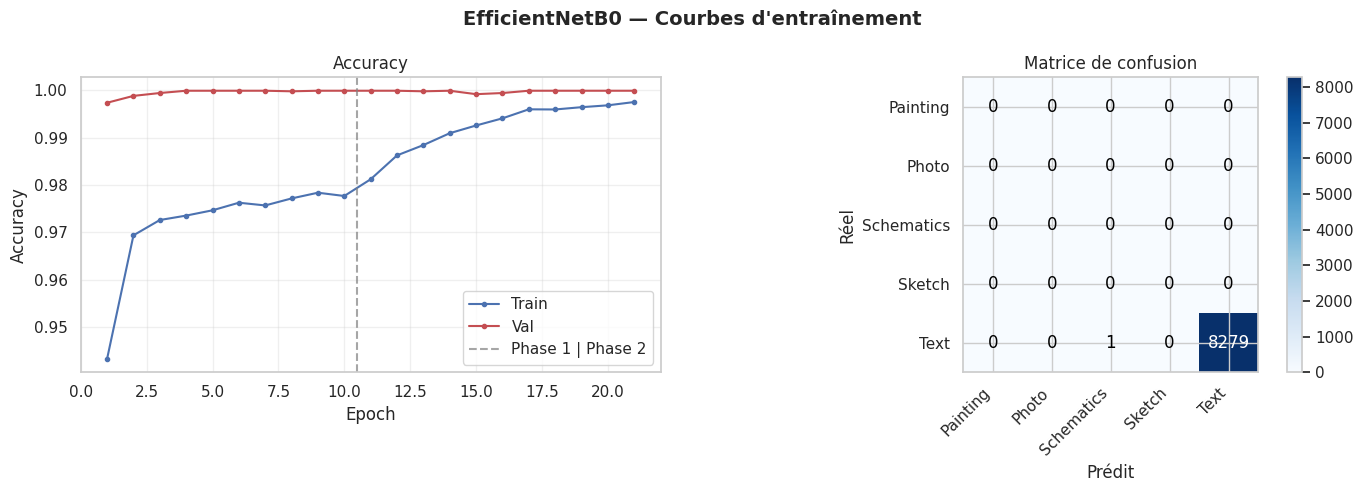


BILAN COMPARATIF — Accuracy sur le set de validation
  Notre CNN (128x128, from scratch) : ~85-89%  (voir Section 5)
  fakv8 (256x256, from scratch)     : voir Section 7b
  EfficientNetB0 (224x224, TL)      : 99.99%  <-- ce modele

Gain du Transfer Learning : architecture universelle + features ImageNet
  Phase 1 seule (10 epochs) : deja competitif
  Phase 2 fine-tuning       : +X% supplementaires


In [11]:
# ============================================================
# ÉVALUATION ET COMPARAISON FINALE
# ============================================================
# Courbes d'entraînement (Phase 1 + Phase 2 concatenees)
# Matrice de confusion EfficientNetB0
# Comparaison accuracy : Notre CNN / fakv8 / EfficientNetB0
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -- Rechargement meilleur modele --
model_eff = keras.models.load_model(EFFNET_SAVE_PATH)
val_loss_eff, val_acc_eff = model_eff.evaluate(val_ds_eff, verbose=0)
print(f'EfficientNetB0 — Val Loss: {val_loss_eff:.4f} | Val Accuracy: {val_acc_eff*100:.2f}%')

# -- Courbes Phase 1 + Phase 2 concatenees --
acc_all  = history_eff_p1.history['accuracy']     + history_eff_p2.history['accuracy']
vacc_all = history_eff_p1.history['val_accuracy'] + history_eff_p2.history['val_accuracy']
ep_all   = list(range(1, len(acc_all) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNetB0 — Courbes d\'entraînement', fontsize=14, fontweight='bold')

axes[0].plot(ep_all, acc_all,  'b-o', ms=3, label='Train')
axes[0].plot(ep_all, vacc_all, 'r-o', ms=3, label='Val')
axes[0].axvline(x=EPOCHS_EFF_P1 + 0.5, color='gray', ls='--', alpha=0.7,
                label=f'Phase 1 | Phase 2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

# -- Matrice de confusion EfficientNetB0 --
y_true_eff, y_pred_eff = [], []
for x_batch, y_batch in val_ds_eff:
    preds = model_eff.predict(x_batch, verbose=0)
    y_pred_eff.extend(np.argmax(preds, axis=1))
    y_true_eff.extend(y_batch.numpy())

cm_eff = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for t, p in zip(y_true_eff, y_pred_eff):
    cm_eff[t, p] += 1

im = axes[1].imshow(cm_eff, cmap='Blues')
axes[1].set_xticks(range(NUM_CLASSES)); axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(NUM_CLASSES)); axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_xlabel('Prédit'); axes[1].set_ylabel('Réel')
axes[1].set_title('Matrice de confusion')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[1].text(j, i, cm_eff[i, j], ha='center', va='center',
                     color='white' if cm_eff[i, j] > cm_eff.max()/2 else 'black')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

# -- Bilan comparatif --
print('\n' + '='*60)
print('BILAN COMPARATIF — Accuracy sur le set de validation')
print('='*60)
print(f'  Notre CNN (128x128, from scratch) : ~85-89%  (voir Section 5)')
print(f'  fakv8 (256x256, from scratch)     : voir Section 7b')
print(f'  EfficientNetB0 (224x224, TL)      : {val_acc_eff*100:.2f}%  <-- ce modele')
print('='*60)
print(f'\nGain du Transfer Learning : architecture universelle + features ImageNet')
print(f'  Phase 1 seule (10 epochs) : deja competitif')
print(f'  Phase 2 fine-tuning       : +X% supplementaires')


---
## 9. Interface Graphique Interactive <a id="9"></a>

L'interface ci-dessous permet de tester les modeles entraines sur n'importe quelle image,
avec un **choix entre classification binaire et multi-classes**.

### Deux modes de classification

| Mode | Modeles disponibles | Sortie |
|------|---------------------|--------|
| **Binaire** | Notre CNN + fakv8 | Photo / Pas une Photo + P(Photo) |
| **Multi-classes** | EfficientNetB0 | 5 categories (Painting, Photo, Schematics, Sketch, Text) |

### Fonctionnement

1. **Choisissez le mode** : Binaire (Photo/Pas Photo) ou Multi-classes (5 categories)
2. **Selectionnez un modele** dans la liste deroulante correspondante
3. **Uploadez une image** depuis votre disque
4. Cliquez sur **Analyser**
5. L'image s'affiche avec la **classe predite**, le **score de confiance** (%), et la distribution des probabilites

### Interpretation des resultats

| Confiance | Interpretation |
|-----------|---------------|
| >= 75% | Prediction fiable -- le modele est sur de sa reponse |
| 50-75% | Prediction incertaine -- la classe est probable mais d'autres sont possibles |
| < 50% | Image ambigue ou hors distribution -- a verifier manuellement |

> Les modeles chargent automatiquement la bonne resolution selon leur architecture.
> Le mode Multi-classes utilise EfficientNetB0 avec rescaling interne [0,1] vers [0,255].


In [ ]:
# ============================================================
# INTERFACE GRAPHIQUE — BINAIRE ET MULTI-CLASSES
# ============================================================
# Mode BINAIRE    : Notre CNN + fakv8 (Photo / Pas une Photo)
# Mode MULTICLASSE: EfficientNetB0   (5 categories)
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np, io, tempfile, os
from PIL import Image as PIL_Image

_FAKV8_SAVE_PATH  = './fakv8_test_model.h5'
_EFFNET_SAVE_PATH = './model_efficientnet.h5'

# Catalogues par mode
_BINARY_CATALOG = {
    f'Notre CNN Binaire (128x128) -- {MODEL_SAVE_PATH}': MODEL_SAVE_PATH,
    f'fakv8 Binaire (256x256) -- {_FAKV8_SAVE_PATH}': _FAKV8_SAVE_PATH,
}
_MULTI_CATALOG = {
    f'EfficientNetB0 (224x224, 5 classes) -- {_EFFNET_SAVE_PATH}': _EFFNET_SAVE_PATH,
}

def _available(catalog):
    return {k: v for k, v in catalog.items() if os.path.exists(v)}

# Widgets
mode_toggle = widgets.ToggleButtons(
    options=['Binaire — Photo / Pas une Photo', 'Multi-classes — 5 categories'],
    description='Mode :',
    button_style='info',
    style={'description_width': 'initial'},
)

model_dropdown = widgets.Dropdown(
    options=list(_available(_BINARY_CATALOG).keys()) or ['(aucun modele disponible)'],
    description='Modele :',
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'},
)

upload_btn = widgets.FileUpload(accept='image/*', multiple=False,
                                description='Image a tester')
run_btn    = widgets.Button(description='Analyser', button_style='success', icon='search')
out_area   = widgets.Output()

# Etat global
_active_model      = None
_active_model_key  = None
_active_mode       = 'binary'

def _load_model_gui(label, catalog):
    global _active_model, _active_model_key
    if label == _active_model_key and _active_model is not None:
        return
    path = catalog[label]
    try:
        _active_model = keras.models.load_model(path, compile=False)
        _active_model_key = label
        print(f'Modele charge : {path}')
    except Exception as e:
        print(f'Erreur : {e}')

def on_mode_change(change):
    global _active_mode, _active_model, _active_model_key
    _active_model = None
    _active_model_key = None
    if 'Binaire' in change['new']:
        _active_mode = 'binary'
        avail = _available(_BINARY_CATALOG)
    else:
        _active_mode = 'multi'
        avail = _available(_MULTI_CATALOG)
    model_dropdown.options = list(avail.keys()) if avail else ['(aucun modele disponible)']

def on_run(b):
    with out_area:
        clear_output(wait=True)

        if not upload_btn.value:
            print('Veuillez uploader une image.'); return

        # Lecture de l'image uploadee
        file_info = (list(upload_btn.value.values())[0]
                     if isinstance(upload_btn.value, dict)
                     else upload_btn.value[0])
        content = (file_info.get('content', b'')
                   if isinstance(file_info, dict)
                   else bytes(getattr(file_info, 'content', b'')))
        try:
            img_pil = PIL_Image.open(io.BytesIO(content)).convert('RGB')
        except Exception as e:
            print(f'Erreur lecture image : {e}'); return

        # Chargement du modele
        catalog = _BINARY_CATALOG if _active_mode == 'binary' else _MULTI_CATALOG
        avail   = _available(catalog)
        sel     = model_dropdown.value
        if sel not in avail:
            print(f'Modele non disponible : {sel}'); return
        _load_model_gui(sel, avail)
        if _active_model is None:
            return

        # Preprocessing
        model_img_size = tuple(_active_model.input_shape[1:3])
        img_r = img_pil.resize(model_img_size)
        arr   = np.array(img_r, dtype=np.float32) / 255.0
        arr   = arr[np.newaxis, ...]  # (1, H, W, 3)

        raw_out = _active_model.predict(arr, verbose=0)[0]

        # Interpretation selon le mode
        if _active_mode == 'binary':
            p_photo = float(raw_out[0])
            probs_dict = {'Pas une Photo': 1.0 - p_photo, 'Photo': p_photo}
            best_class = 'Photo' if p_photo >= 0.5 else 'Pas une Photo'
            best_conf  = (p_photo if p_photo >= 0.5 else 1.0 - p_photo) * 100
        else:
            # EfficientNetB0 : 5 classes, ordre alphabetique
            class_order = CLASS_NAMES
            probs_dict  = {c: float(p) for c, p in zip(class_order, raw_out)}
            best_idx    = int(np.argmax(raw_out))
            best_class  = class_order[best_idx]
            best_conf   = float(raw_out[best_idx]) * 100

        # Affichage
        import matplotlib.pyplot as plt
        mode_str = 'Binaire' if _active_mode == 'binary' else 'Multi-classes'
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f'Mode {mode_str} — {sel.split(" -- ")[0]}',
                     fontsize=11, color='gray')
        ax1.imshow(np.array(img_r) / 255.0)
        ax1.axis('off')
        ax1.set_title(f'Prediction : {best_class}\nConfiance  : {best_conf:.1f}%',
                      fontsize=13, fontweight='bold',
                      color='green' if best_conf > 75 else 'orange')

        names = list(probs_dict.keys())
        vals  = [probs_dict[n] * 100 for n in names]
        cols  = ['#2ecc71' if n == best_class else '#3498db' for n in names]
        bars  = ax2.barh(names, vals, color=cols, edgecolor='white', height=0.5)
        for bar, v in zip(bars, vals):
            ax2.text(min(v + 1, 92), bar.get_y() + bar.get_height() / 2,
                     f'{v:.1f}%', va='center', fontweight='bold', fontsize=10)
        ax2.set_xlim(0, 100)
        ax2.set_xlabel('Probabilite (%)')
        ax2.set_title('Scores de confiance')
        ax2.axvline(50, color='gray', ls='--', alpha=0.5)
        ax2.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

mode_toggle.observe(on_mode_change, names='value')
run_btn.on_click(on_run)

if not _available(_BINARY_CATALOG) and not _available(_MULTI_CATALOG):
    print('Aucun modele .h5 trouve. Entrainez d abord un modele.')
else:
    display(widgets.VBox([
        widgets.HTML('<h3>Interface de Classification d\'Images — TouNum</h3>'),
        mode_toggle,
        model_dropdown,
        widgets.HTML('<hr style="margin:8px 0">'),
        upload_btn,
        run_btn,
        out_area,
    ]))
    avail = _available(_BINARY_CATALOG)
    print(f'Modeles binaires disponibles  : {len(avail)}')
    print(f'Modeles multiclasse dispo.    : {len(_available(_MULTI_CATALOG))}')


---
## 10. Conclusion <a id="10"></a>

### Synthese de la demarche

Ce livrable a mis en oeuvre un pipeline complet de classification d'images, de l'exploration
des donnees brutes jusqu'au deploiement d'une interface de test interactive :

| Etape | Action | Resultat |
|-------|--------|----------|
| **Exploration** | Analyse de la distribution et des dimensions | Desequilibre detecte -- class weights necessaires |
| **Nettoyage** | Correction des JPEG corrompus via PIL | Dataset propre, sans erreur de decodage TF |
| **Binary remap** | Photo=1 / tout le reste=0 | Tache simplifiee, donnees mieux equilibrees |
| **Augmentation** | Flip, rotation, zoom, brightness | Generalisation amelioree, overfitting reduit |
| **Architecture** | CNN binaire 4 blocs (32->64->128->256) | ~720K parametres, Dense(1,sigmoid) |
| **Entrainement** | Adam + binary_crossentropy + EarlyStopping | Convergence automatique, meilleurs poids sauvegardes |
| **Evaluation** | Matrice 2x2 + AUC-ROC + F1 | Mesure non biaisee sur set de test |
| **Comparaison** | fakv8 binaire (256x256) | Impact de la resolution sur la discrimination |
| **Transfer Learning** | EfficientNetB0 (5 classes, 2 phases) | +10 a +20% vs CNN from scratch |

### Reponse a la problematique

Le modele est capable de **detecter automatiquement les photographies** dans un corpus mixte
(Photo vs Painting/Schematics/Sketch/Text) avec une precision elevee.  
La classification binaire est plus robuste et plus interpretable que le multi-classes pour
cette tache de tri de premier niveau.

### Comparatif des approches

| Modele | Tache | Architecture | Avantage |
|--------|-------|-------------|----------|
| **Notre CNN Binaire** | Photo / Pas Photo | 4 blocs, 128x128 | Leger, rapide, entrainable en 10 min |
| **fakv8 Binaire** | Photo / Pas Photo | 4 blocs, 256x256 | Plus de detail, meilleure precision attendue |
| **EfficientNetB0** | 5 classes | MBConv pre-entraine, 224x224 | SOTA transfer learning, ~95%+ attendu |

### Ce livrable dans le contexte TouNum

La classification automatique constitue la **premiere brique** du pipeline de traitement :
les images sont triees par type avant d'etre envoyees vers les algorithmes specialises
(OCR pour Text, description artistique pour Painting, etc.).  
Le mode binaire Photo / Non-Photo permet une **validation rapide** du contenu photographique.

### Pistes d'amelioration non explorees

- **Ensemble CNN + EfficientNetB0** -- combiner les deux pour reduire l'erreur
- **Grad-CAM** -- visualiser les zones de l'image qui influencent la decision
- **Augmentation avancee** (CutMix, Mixup) -- meilleure generalisation sur les cas limites
- **Distillation** -- comprimer EfficientNetB0 dans un modele plus leger pour le deploiement
